Цель: Провести полный цикл разведывательного анализа временного ряда, определить его природу, преобразовать в облако точек методами равномерного и неравномерного вложения, и выявить скрытые паттерны с помощью TDA и кластеризации.

### Задания

1. Разведывательный анализ (EDA) и предобработка

- Проверьте данные на пропуски. Обоснуйте метод их заполнения (LOCF, интерполяция и т.д.), учитывая риск упреждения (look-ahead bias).
    
- Постройте графики временного ряда, опишите визуально наблюдаемые особенности.
    

2. Определение природы порождающего процесса

- Вычислите показатель Ляпунова.
    
- Вычислите показатель Хёрста (R/S-анализ).
    
- Опираясь на полученные значения, сделайте обоснованный вывод о природе порождающих процессов.
    

3. Вложение временного ряда  
На основе выводов из п.2 преобразуйте одномерный временной ряд в многомерное облако точек.

- Равномерное вложение (Uniform Embedding):
    

- Определите оптимальные временную задержку и размерность вложения.
    

- Неравномерное вложение (Non-uniform Embedding):
    

- Определите оптимальные различные (неравномерные) шаги задержки (размерность определяется одновременно).
    

- Анализ: Визуализируйте полученные облака точек (в 2D или 3D проекциях, например, через PCA/UMAP). Сравните структуру аттракторов, полученных равномерным и неравномерным методами.
    

4. Топологический анализ (TDA) и выявление скрытых режимов  
Поскольку данные неразмеченные, задача сводится к поиску скрытых режимов (например, смена режимы работы оборудования).

- Примените метод персистентных гомологий (постройте симплициальные комплексы) к полученным на шаге 3 облакам точек.
    
- Постройте диаграммы персистентности.
    
- Векторизуйте диаграммы.
    

- Ландшафты персистентности (Persistence Landscapes).
    
- Образы персистентности (Persistence Images).
    
- Кривые Бетти (Betti Curves).
    
- Кривые Эйлера.
    
- Характеристики диаграмм персистентности и/или их векторизаций.
    

- Примените алгоритмы кластеризации к полученным топологическим признакам.
    
- Интерпретация: Сопоставьте найденные кластеры с исходным временным рядом (раскрасьте график временного ряда цветами кластеров). Объясните, какие режимы смогла найти топология.

### Подключение библиотек

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import entropy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

import nolds

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

/Users/lidakarpovich/miniconda3/envs/tda/lib/python3.11/site-packages/nolds/datasets.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape
from gtda.diagrams import PersistenceImage
from gtda.diagrams import BettiCurve
from gtda.diagrams import PairwiseDistance

In [3]:
from juliacall import Main as jl
from swpy import Timer
from teaspoon.parameter_selection.FNN_n import FNN_n
from teaspoon.parameter_selection.MI_delay import MI_for_delay

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [4]:
jl.seval("using DelayEmbeddings")
jl.seval("using DynamicalSystems")

# Разведывательный анализ (EDA) и предобработка

## Загрузка данных

In [5]:
df = pd.read_parquet('./Lab5_Разрушение подшипника КНД КС-5 ГПА 14.parquet')

In [6]:
df

,row,TS,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,...,Lab5_AVOM_AVOMN1,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_6,Lab5_U_Kran_GPA_A_APK,Lab5_Kran_1,Lab5_Kran_4,Lab5_q
0,1,2021-01-04 17:00:00+00:00,9258,11923,4948,15.43,706.0,-3.7,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
1,2,2021-01-04 17:00:00+00:00,9258,11923,4948,15.43,706.0,-3.7,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
2,3,2021-01-04 17:00:59.999999+00:00,9256,11927,4943,15.41,706.6,-3.5,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
3,4,2021-01-04 17:00:59.999999+00:00,9256,11927,4943,15.41,706.6,-3.5,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
4,5,2021-01-04 17:01:59.999999+00:00,9256,11924,4960,15.45,706.1,-3.7,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2575,2576,2021-01-05 14:26:59.999999+00:00,0,0,0,0.14,280.7,-1.3,40.7,81.20,...,1,0.00,0.00,1,0,0,0,0,0,0.0
2576,2577,2021-01-05 14:28:00+00:00,0,0,0,0.13,310.9,-0.9,40.5,79.64,...,1,0.00,0.00,1,0,0,0,0,0,0.0
2577,2578,2021-01-05 14:28:00+00:00,0,0,0,0.13,310.9,-0.9,40.5,79.64,...,1,0.00,0.00,1,0,0,0,0,0,0.0
2578,2579,2021-01-05 14:28:01+00:00,0,0,0,0.13,310.9,-0.9,40.5,79.64,...,1,0.00,0.00,1,0,0,0,0,0,0.0


Удалим колонки row и TS за ненадобностью:

In [7]:
df = df.drop(columns=['row', 'TS'], errors='ignore')

Проверим, повторяются ли строки в наборе данных и наличие пропусков:

In [8]:
df.isna().sum().sum()

0

При рассмотре данных выявлено, что уже удаленный столбец TS содержит повторяющиеся значения. 1-е совпадает со 2-м, 3-е с 4-м и т.д. Провериим, верно это ли для всех строк и столбцов:

In [9]:
is_ok = df.iloc[1::2].reset_index(drop=True).equals(
    df.iloc[0::2].reset_index(drop=True)
)
print(is_ok)

True


Так как результат проверки положительный, то удаляем дубликаты:

In [10]:
df = df.iloc[::2].reset_index(drop=True)

## Визуализация

### Построение графиков временных рядов

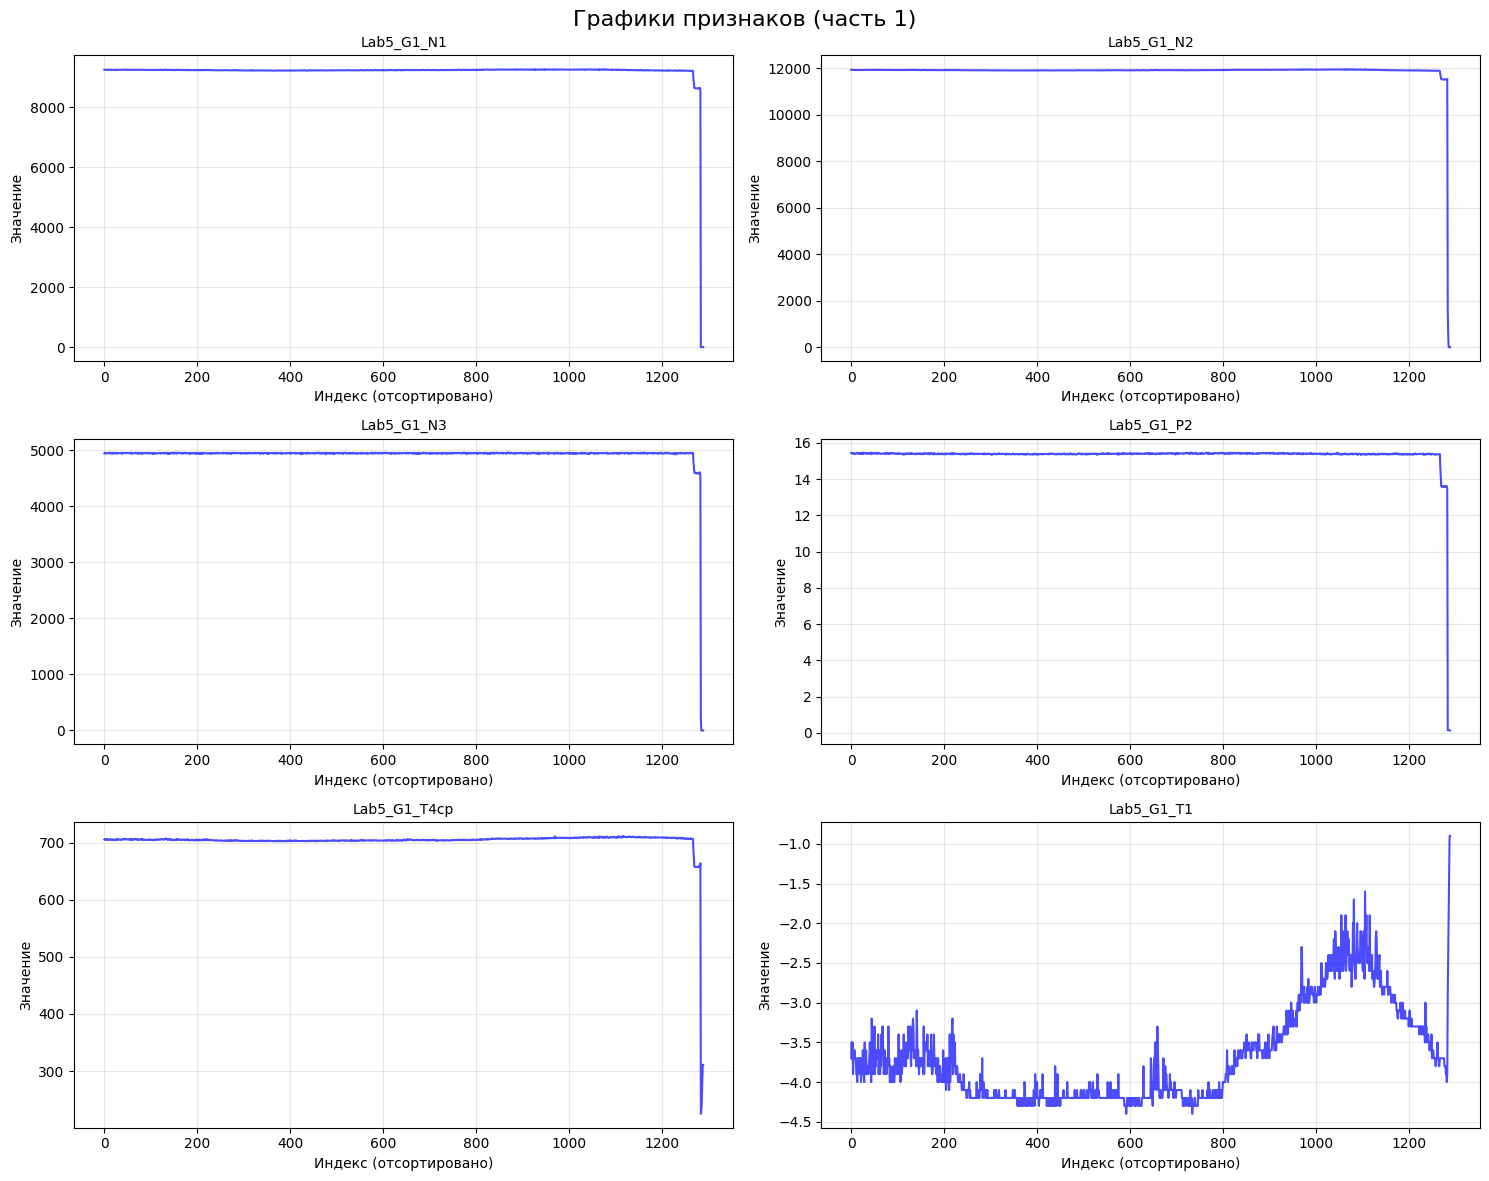

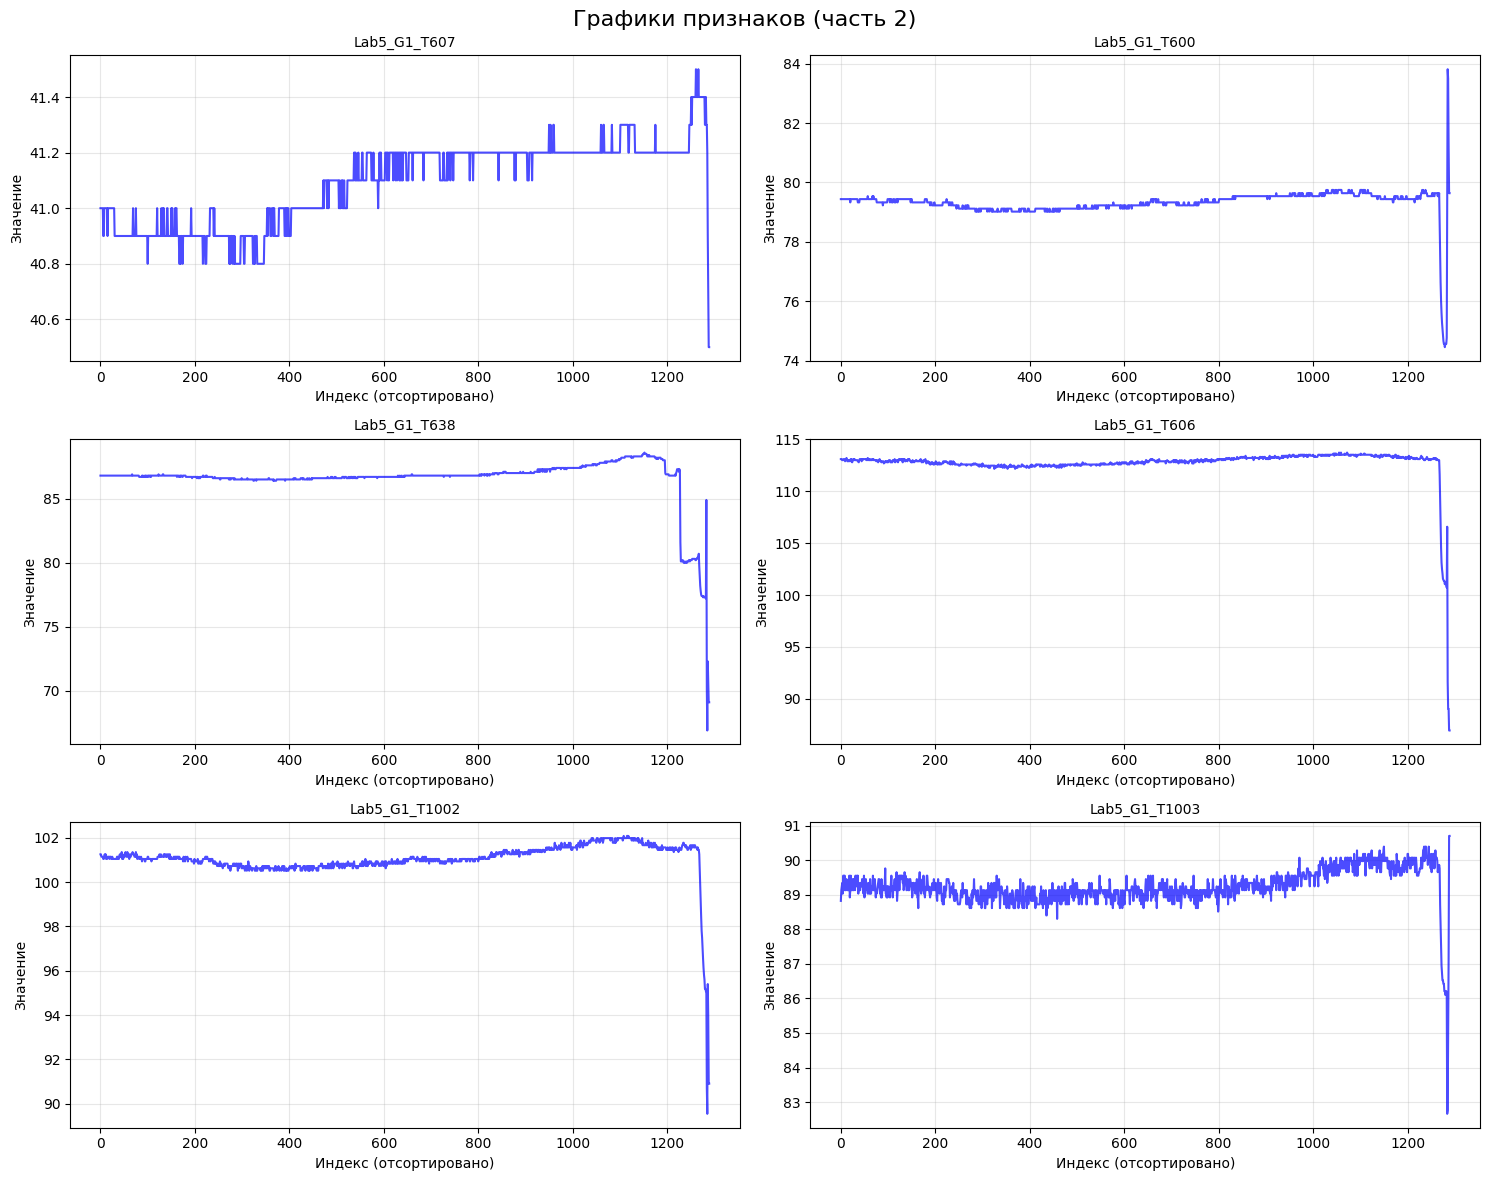

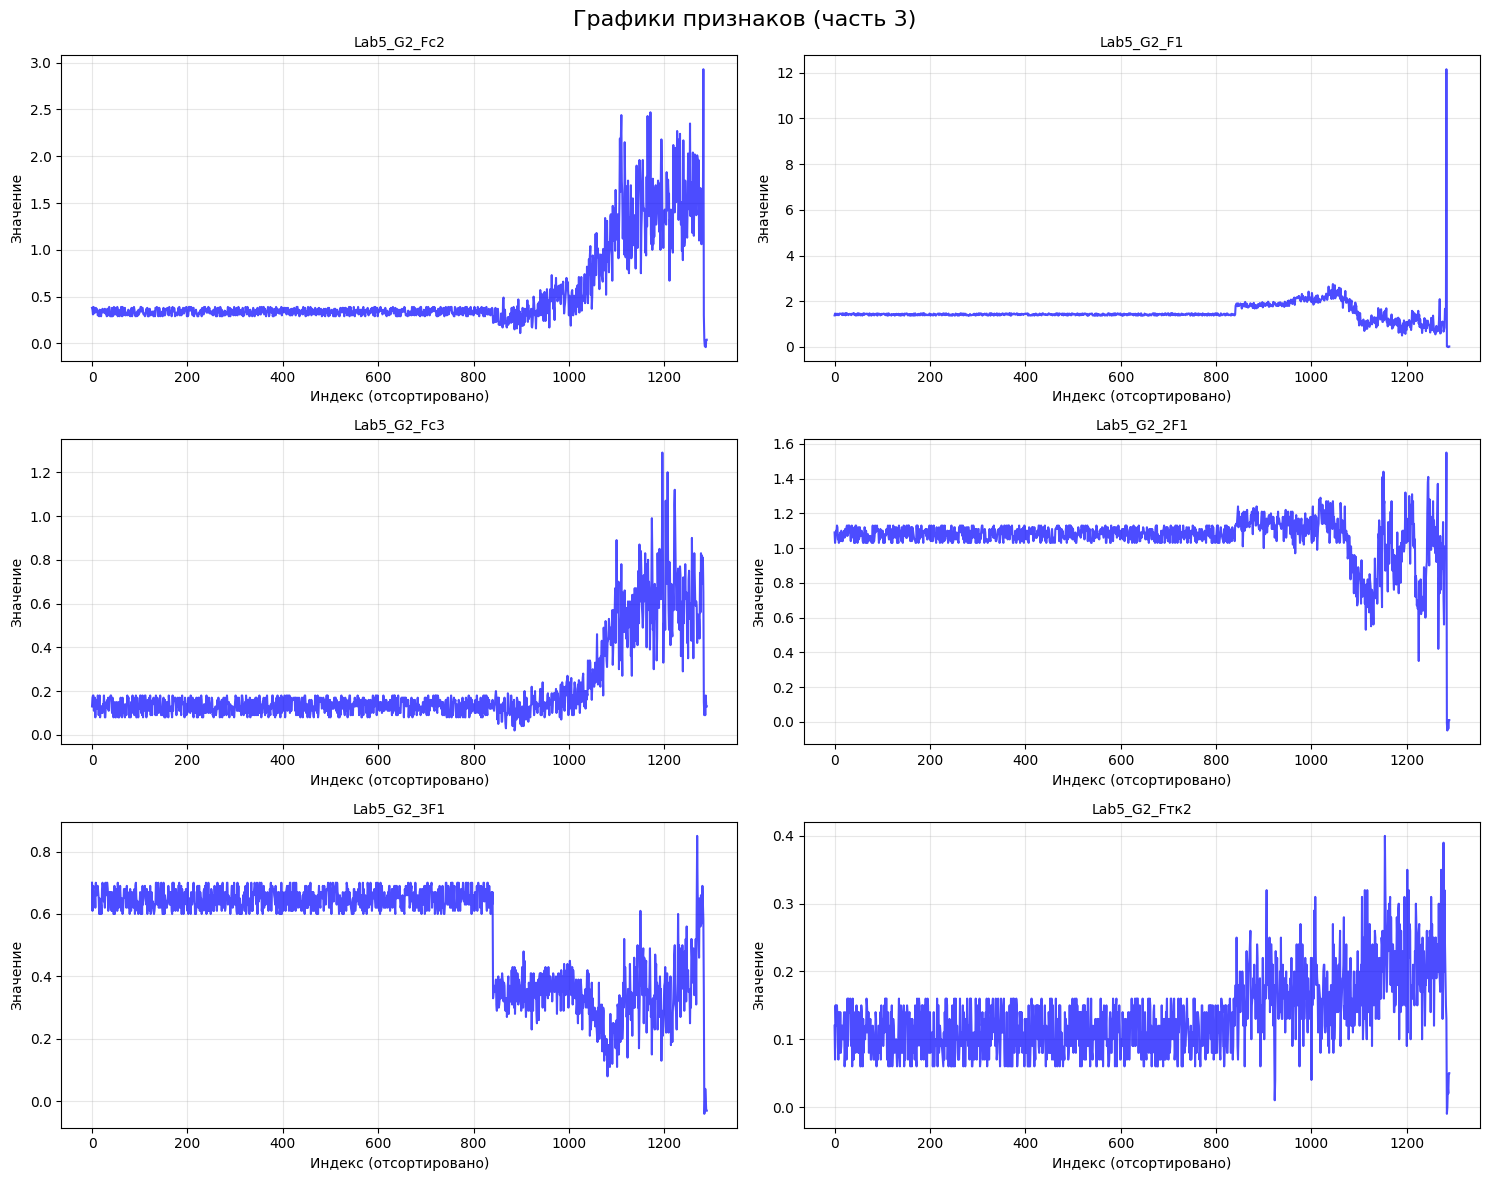

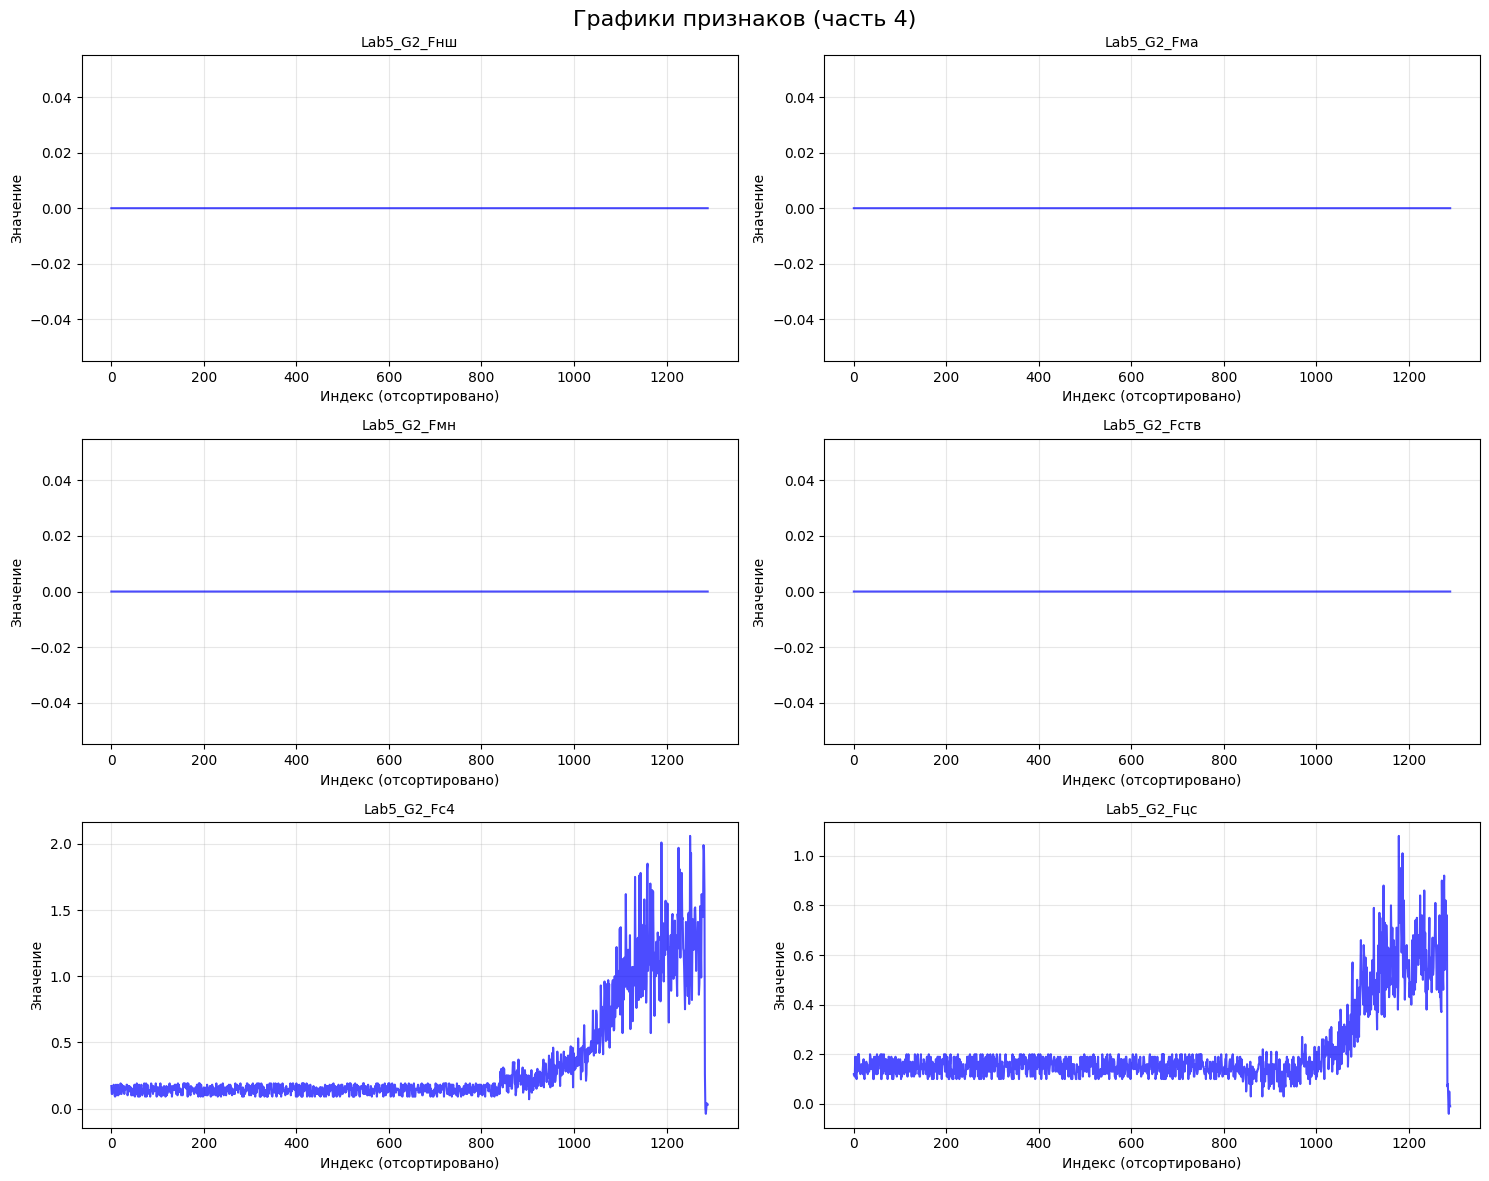

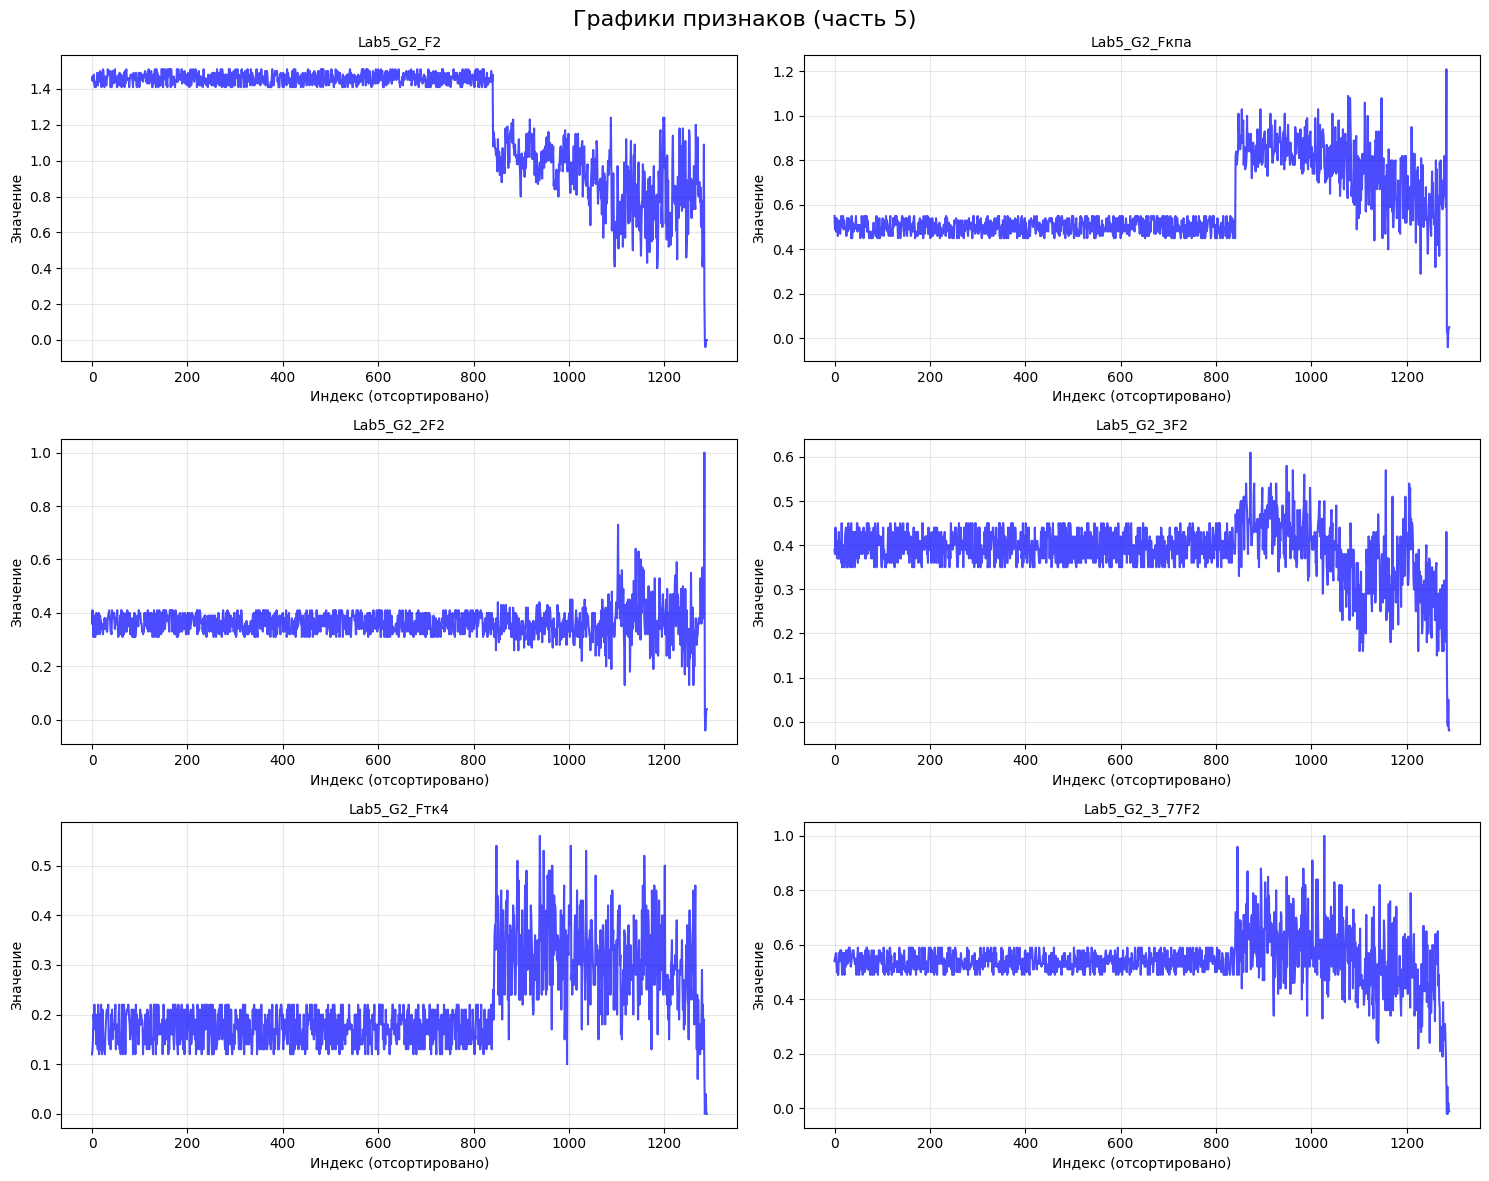

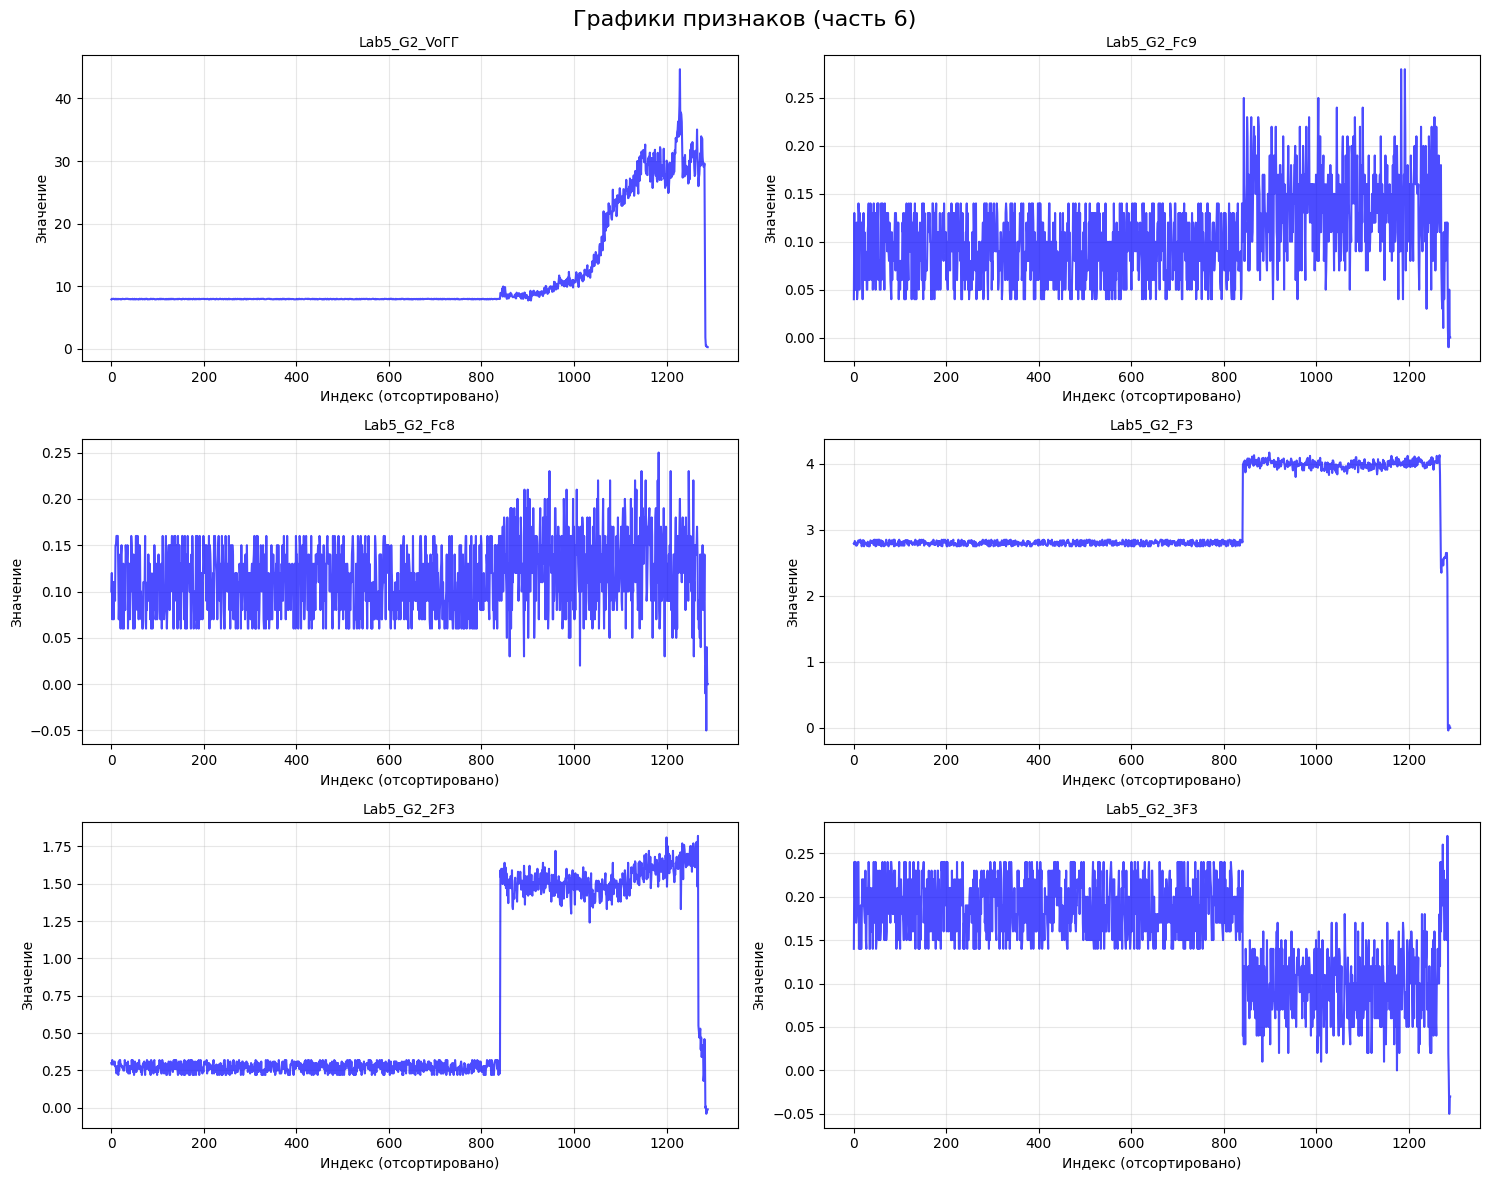

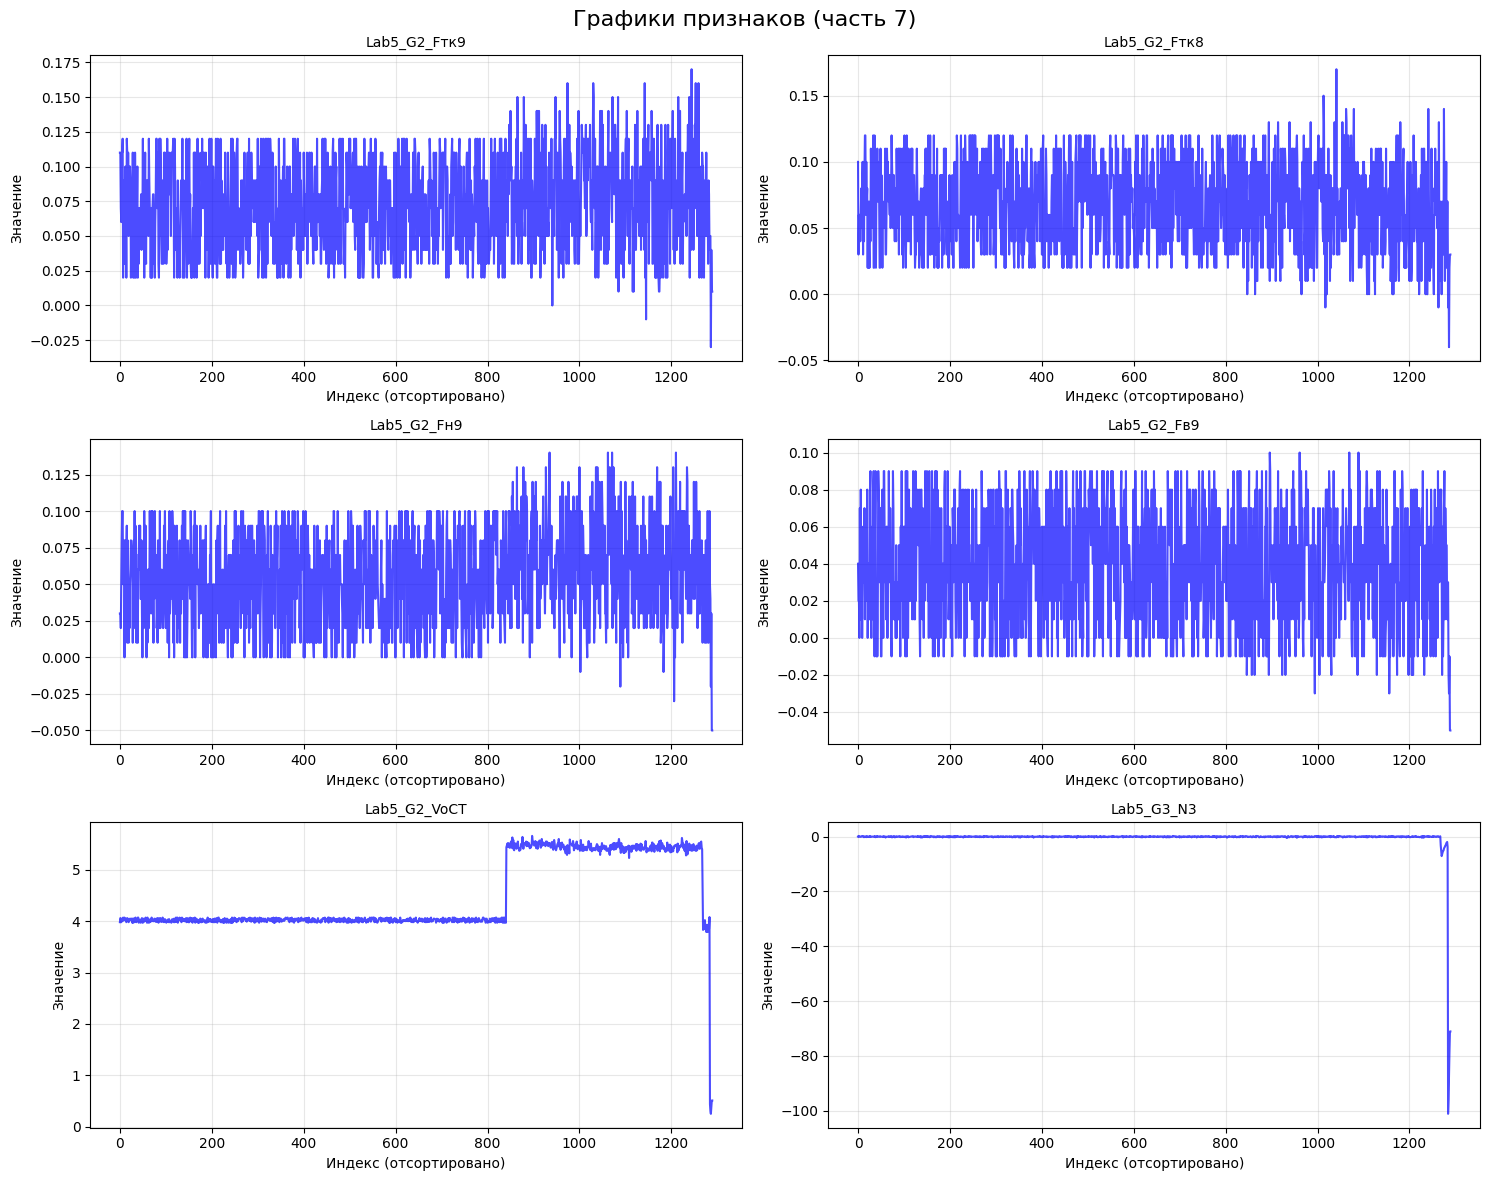

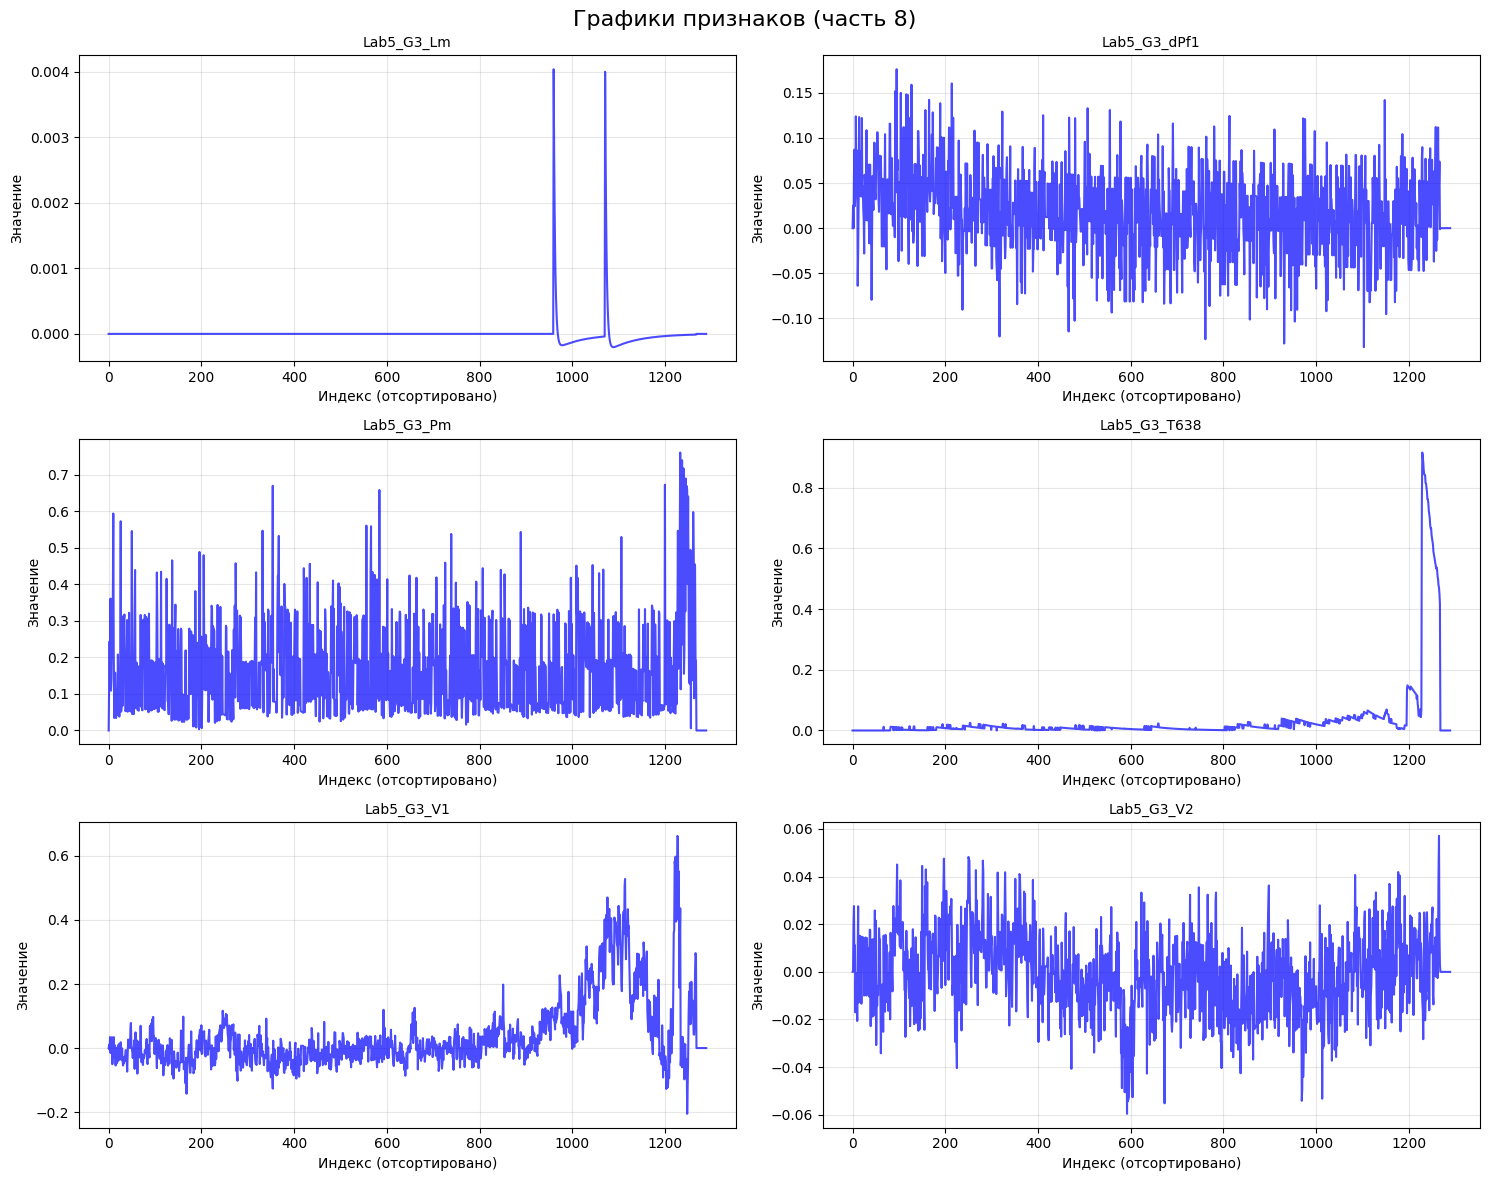

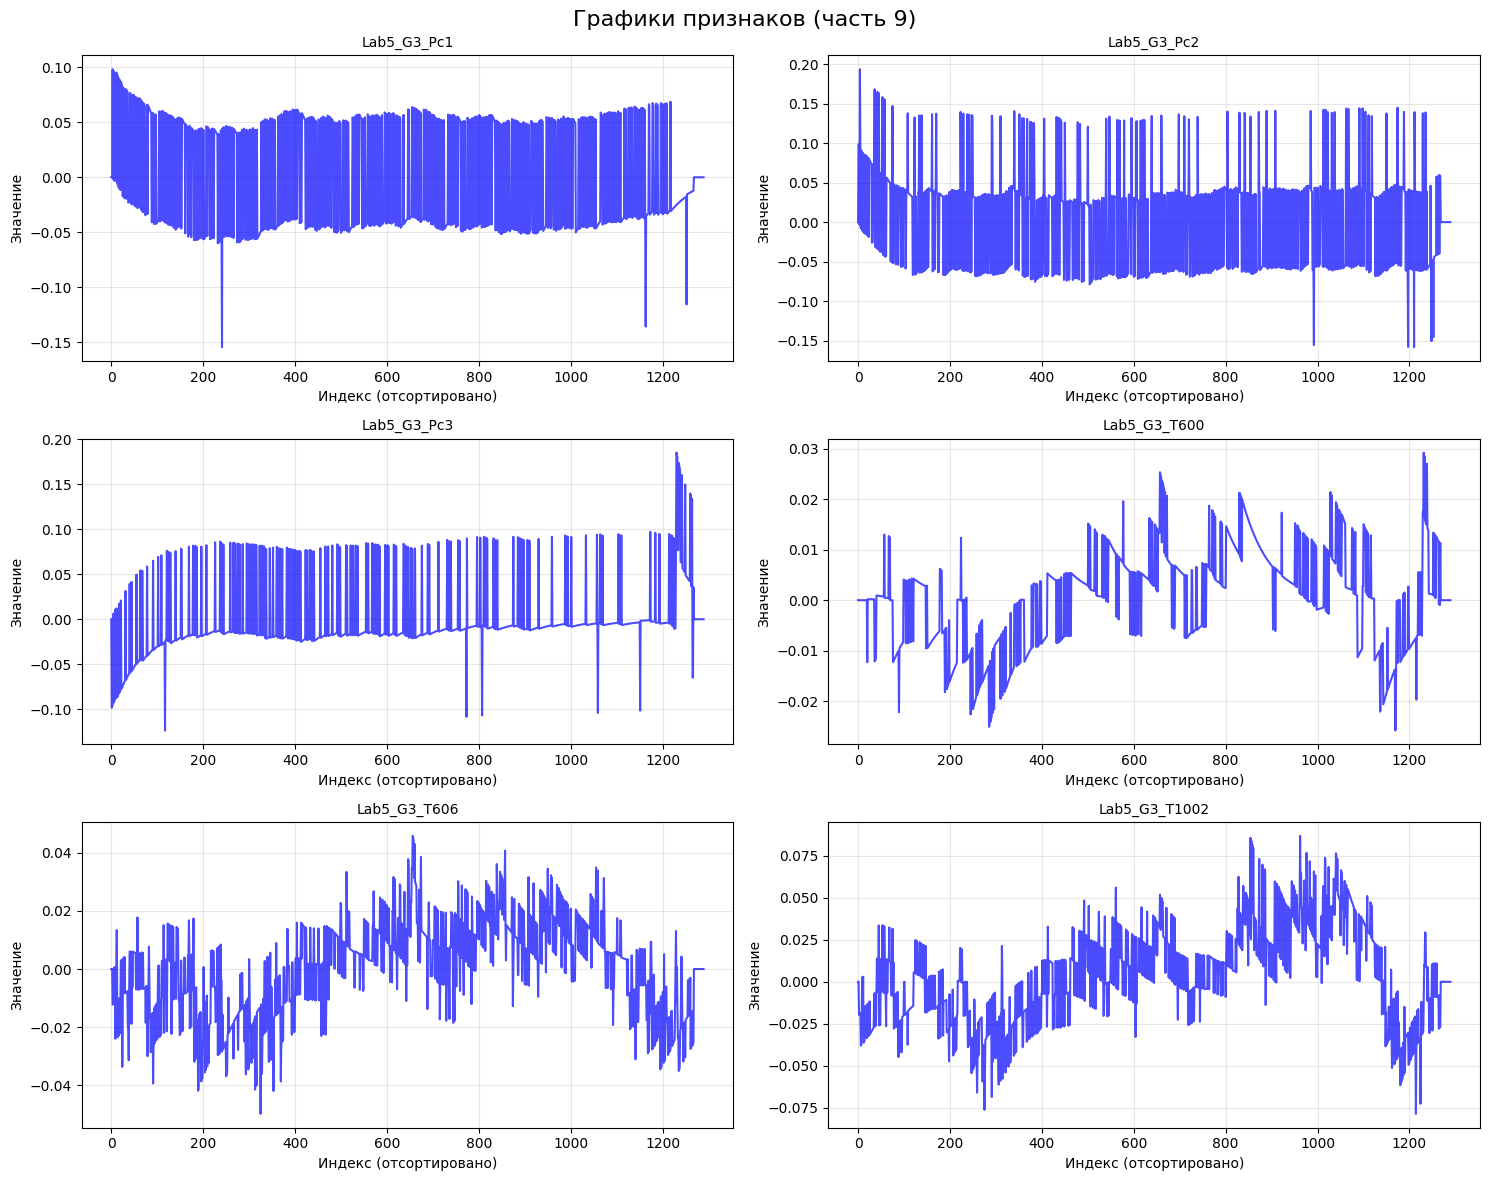

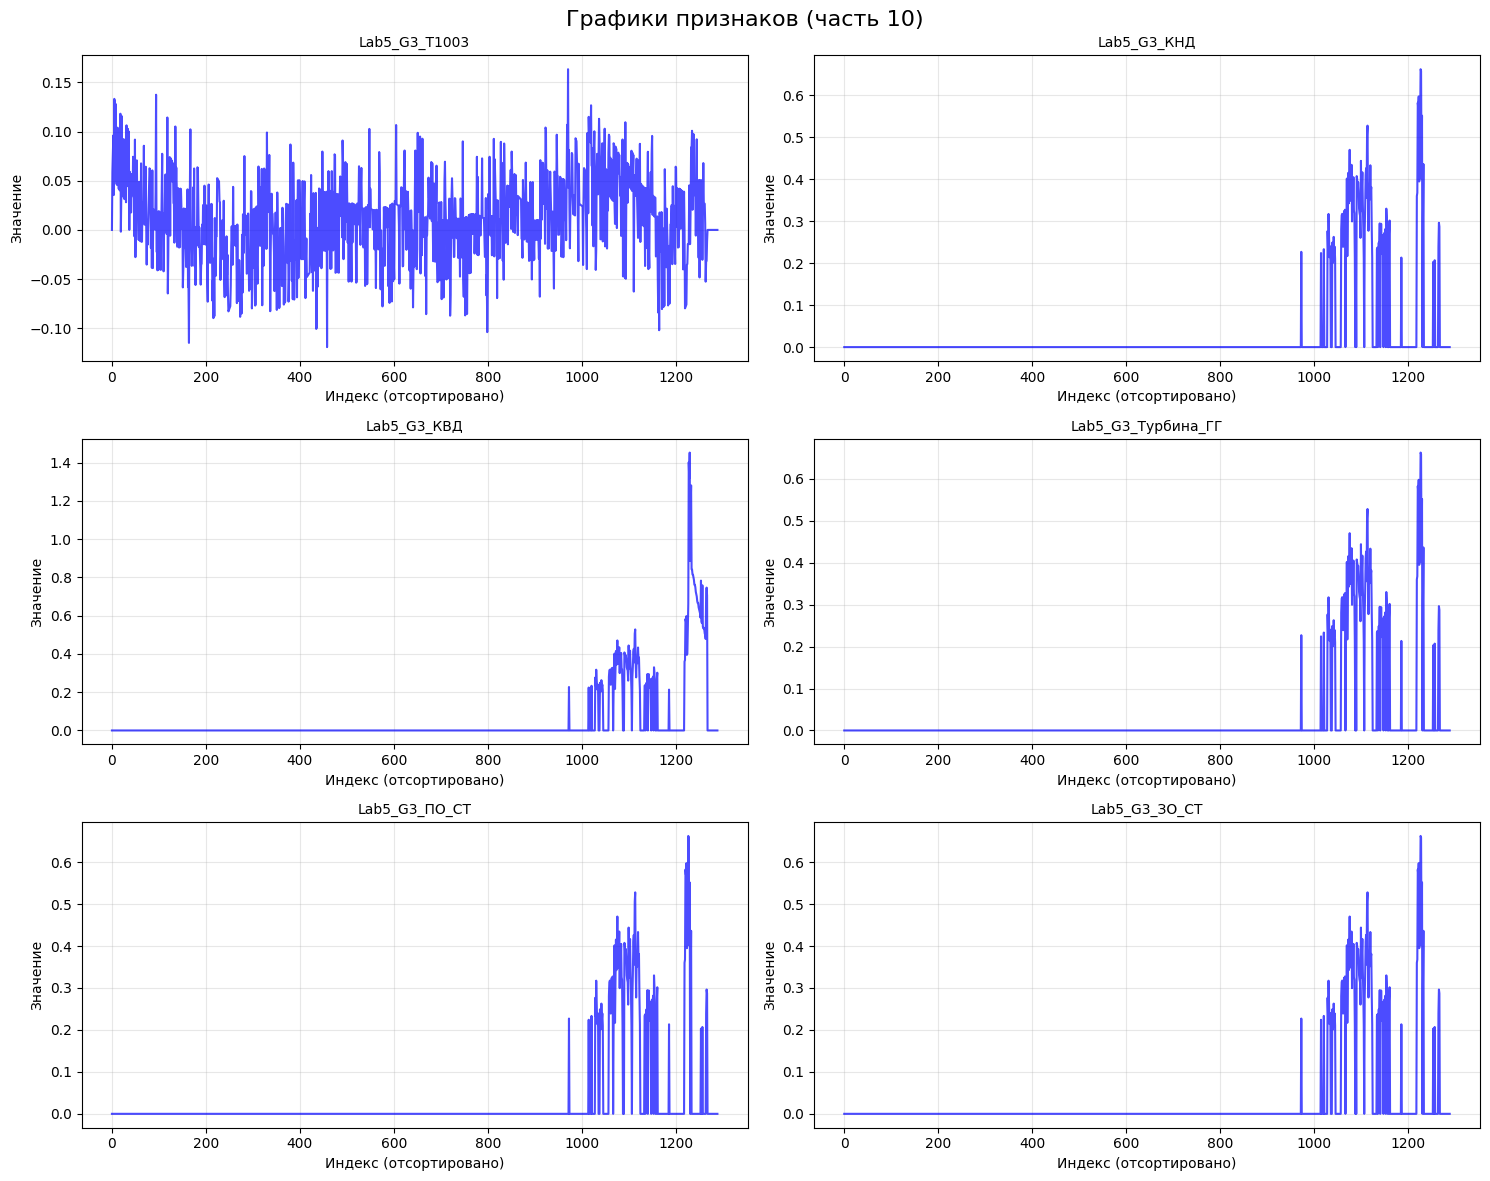

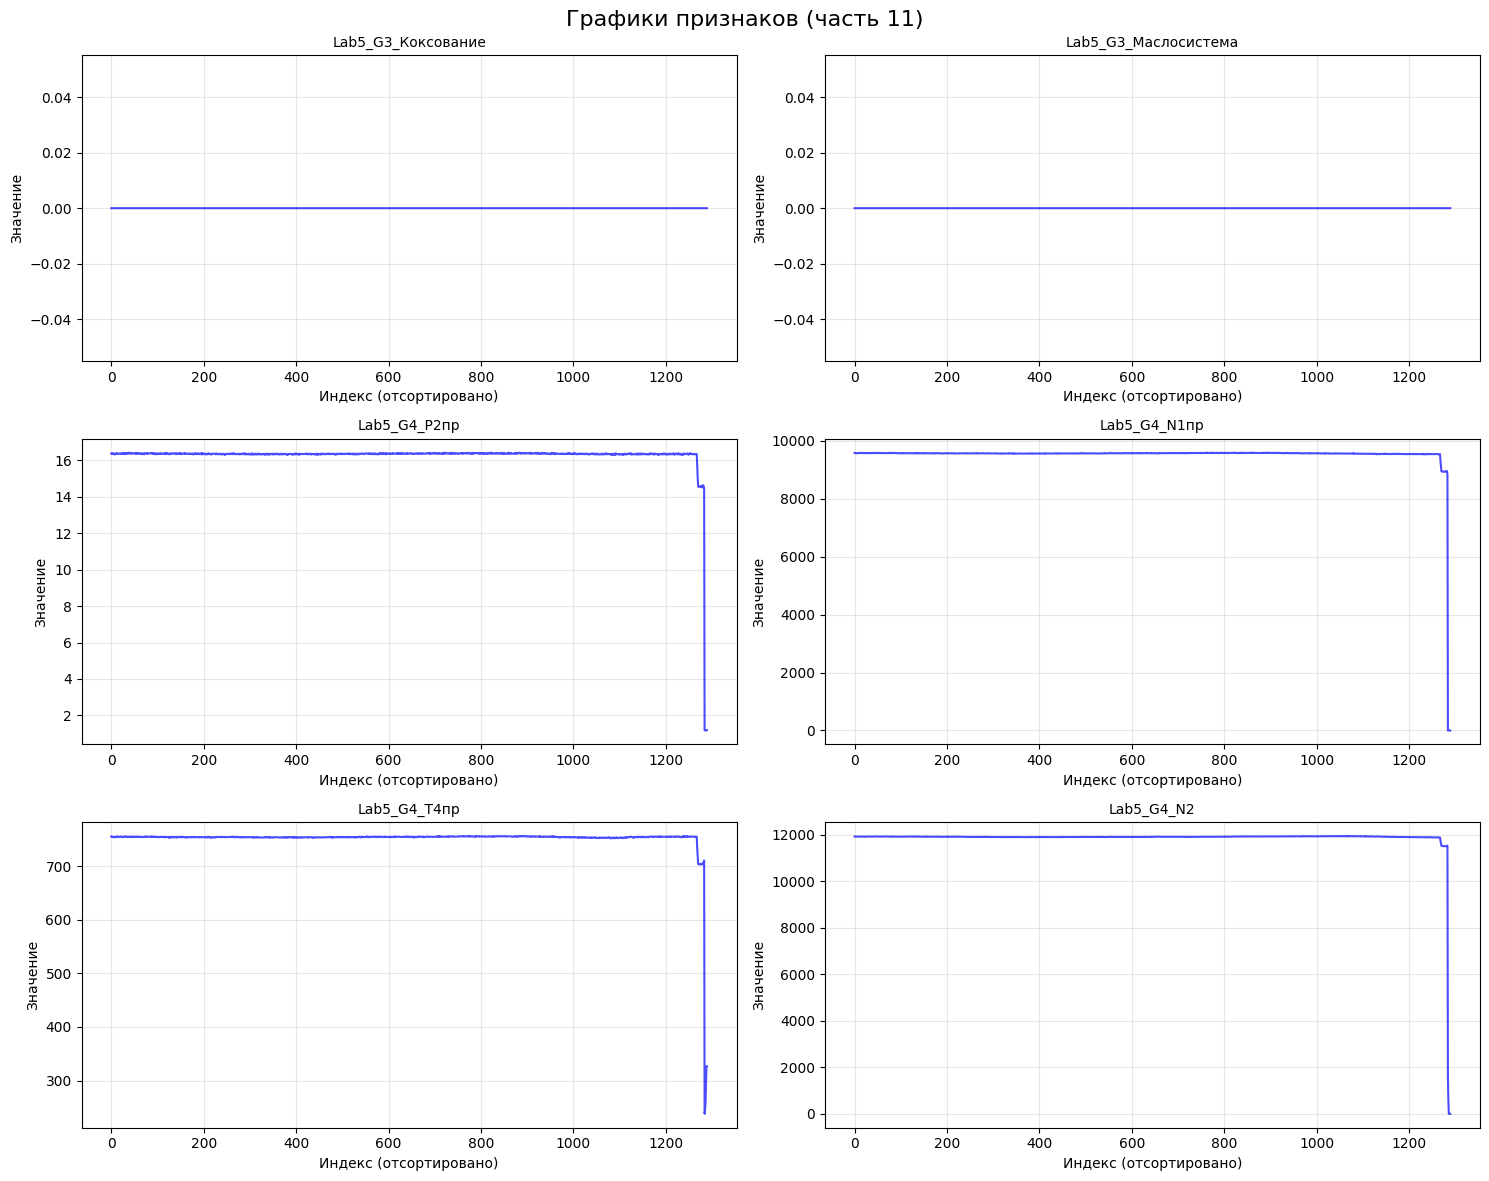

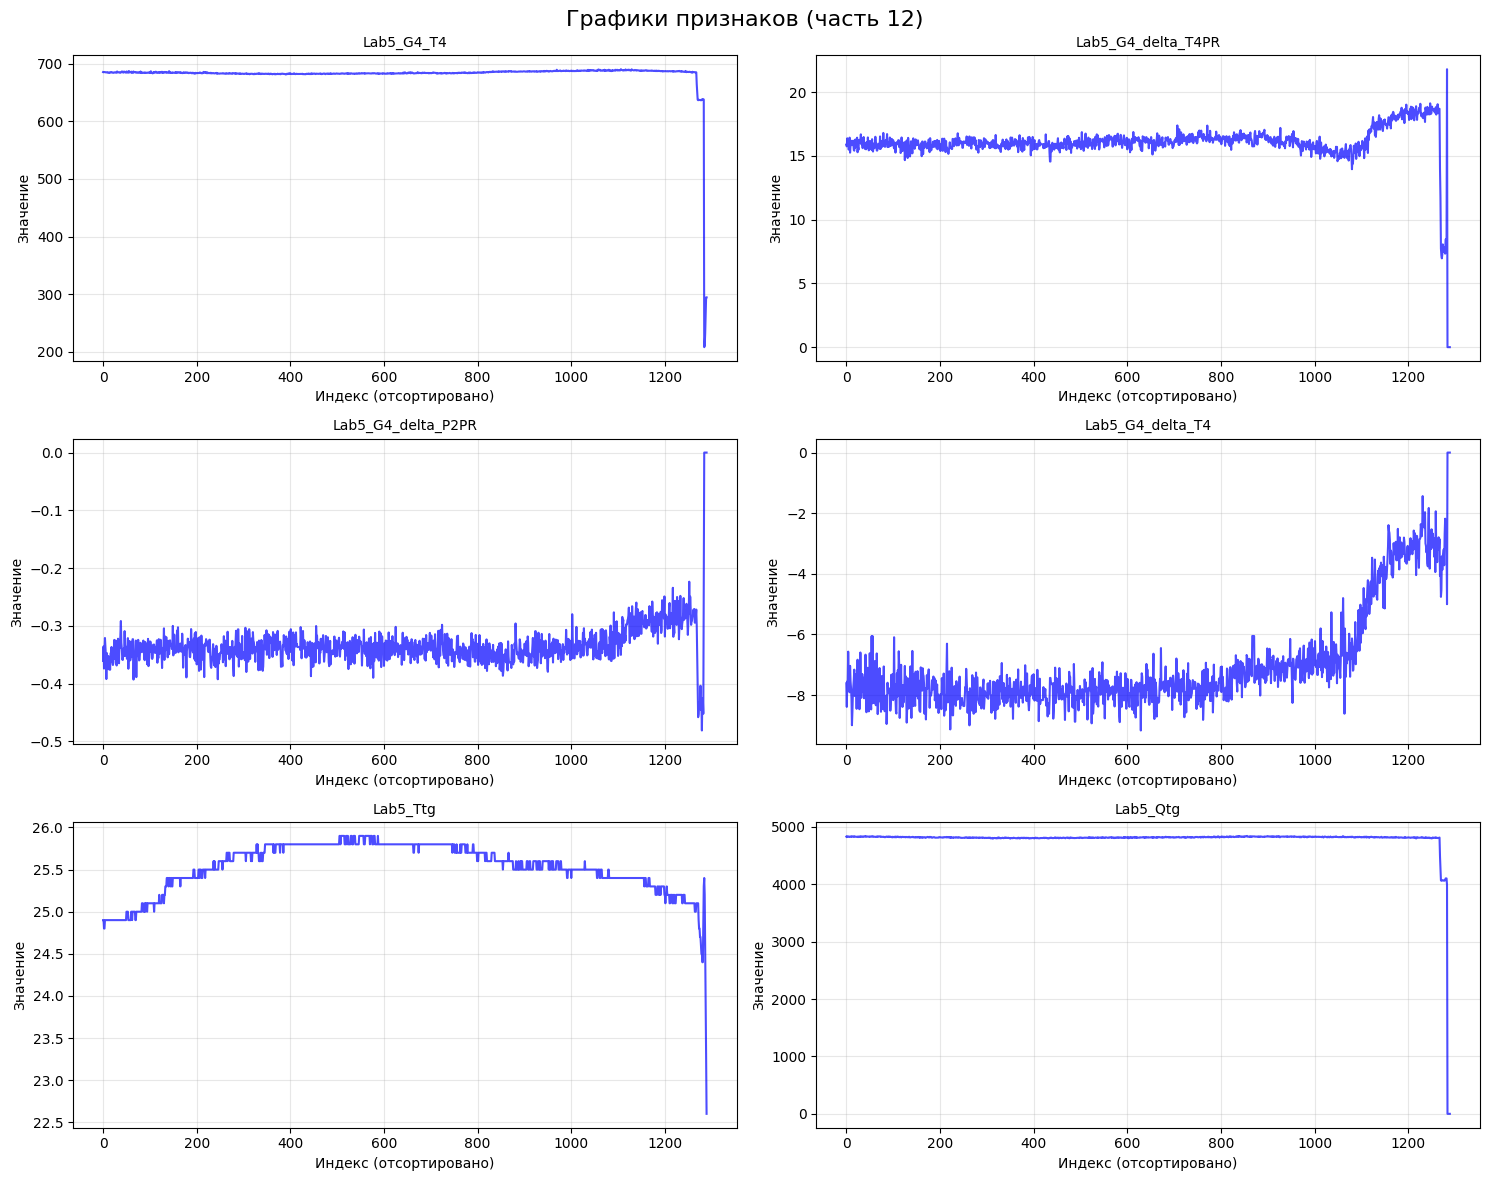

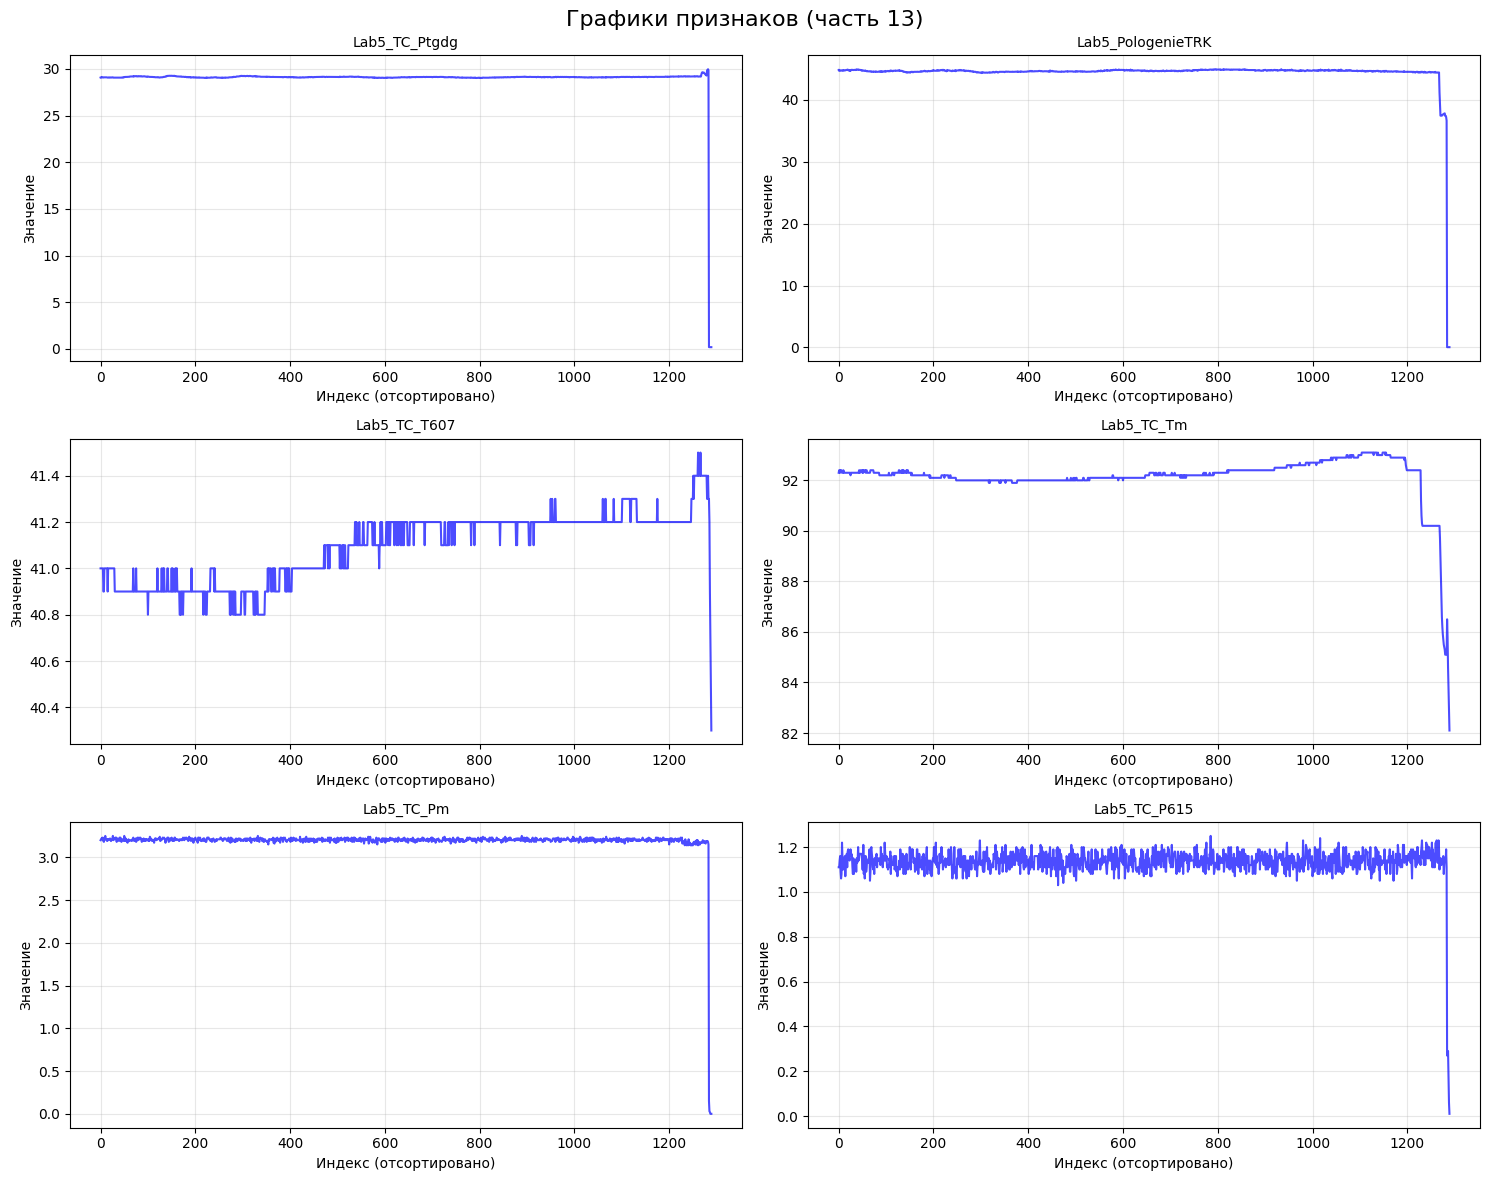

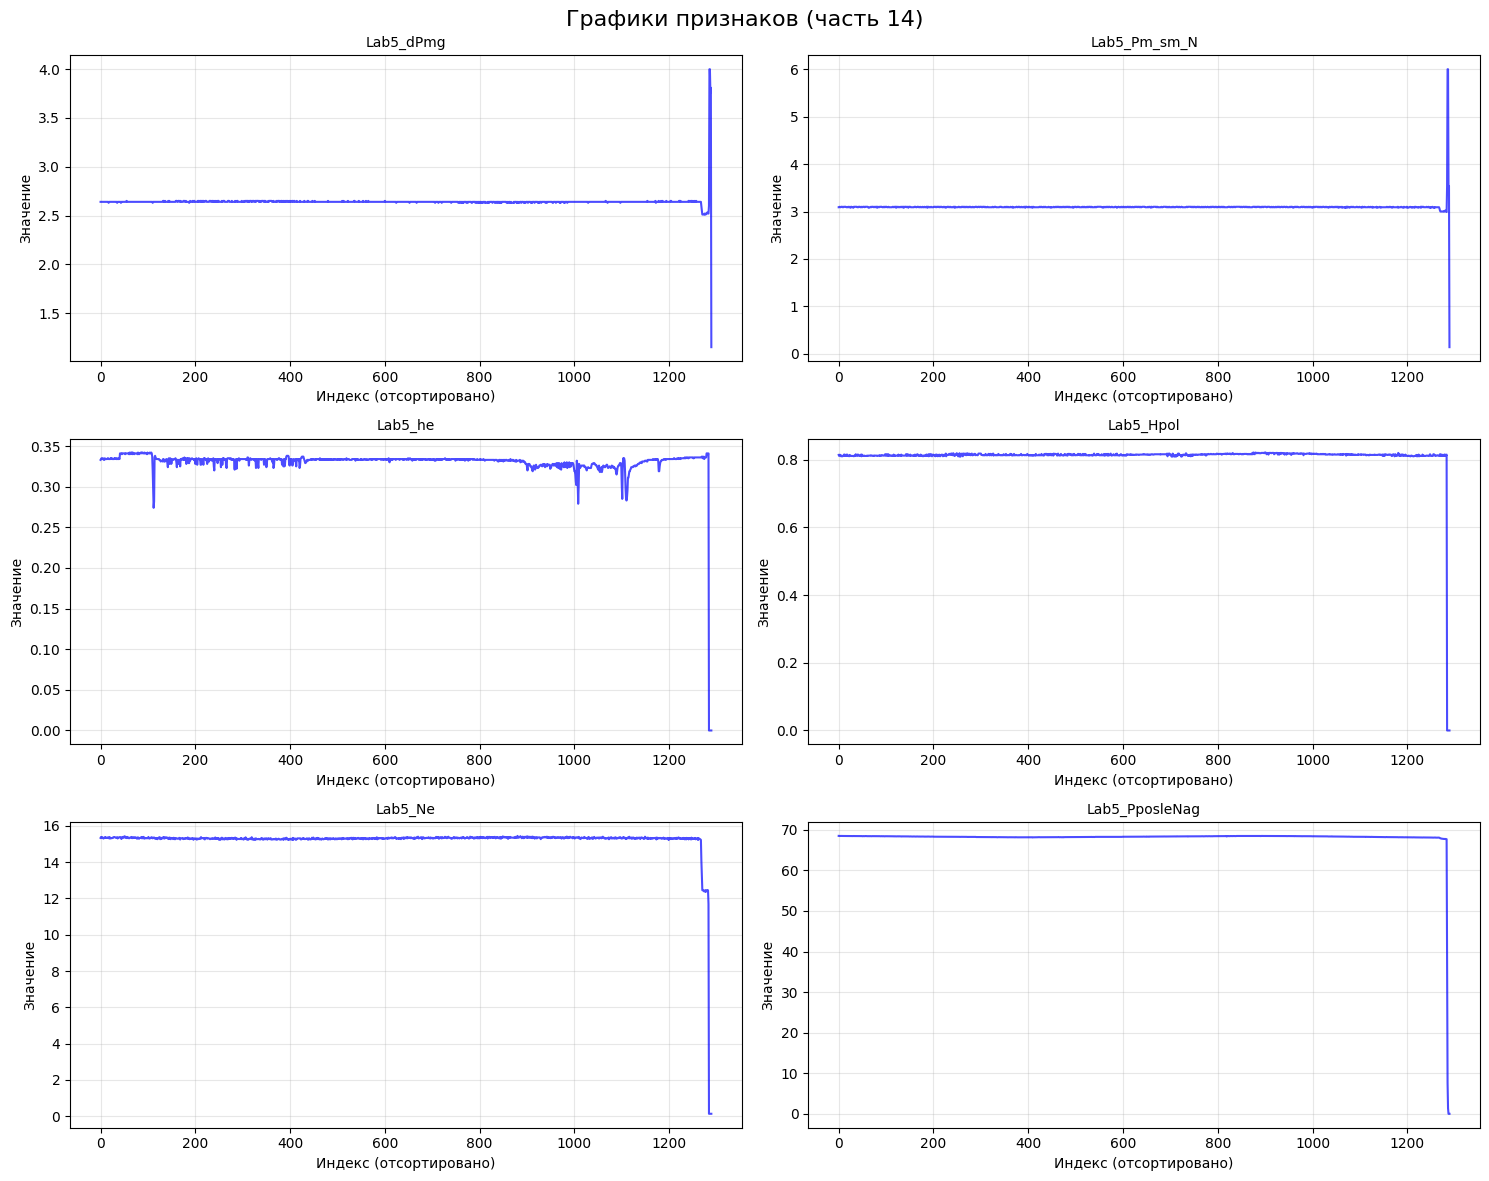

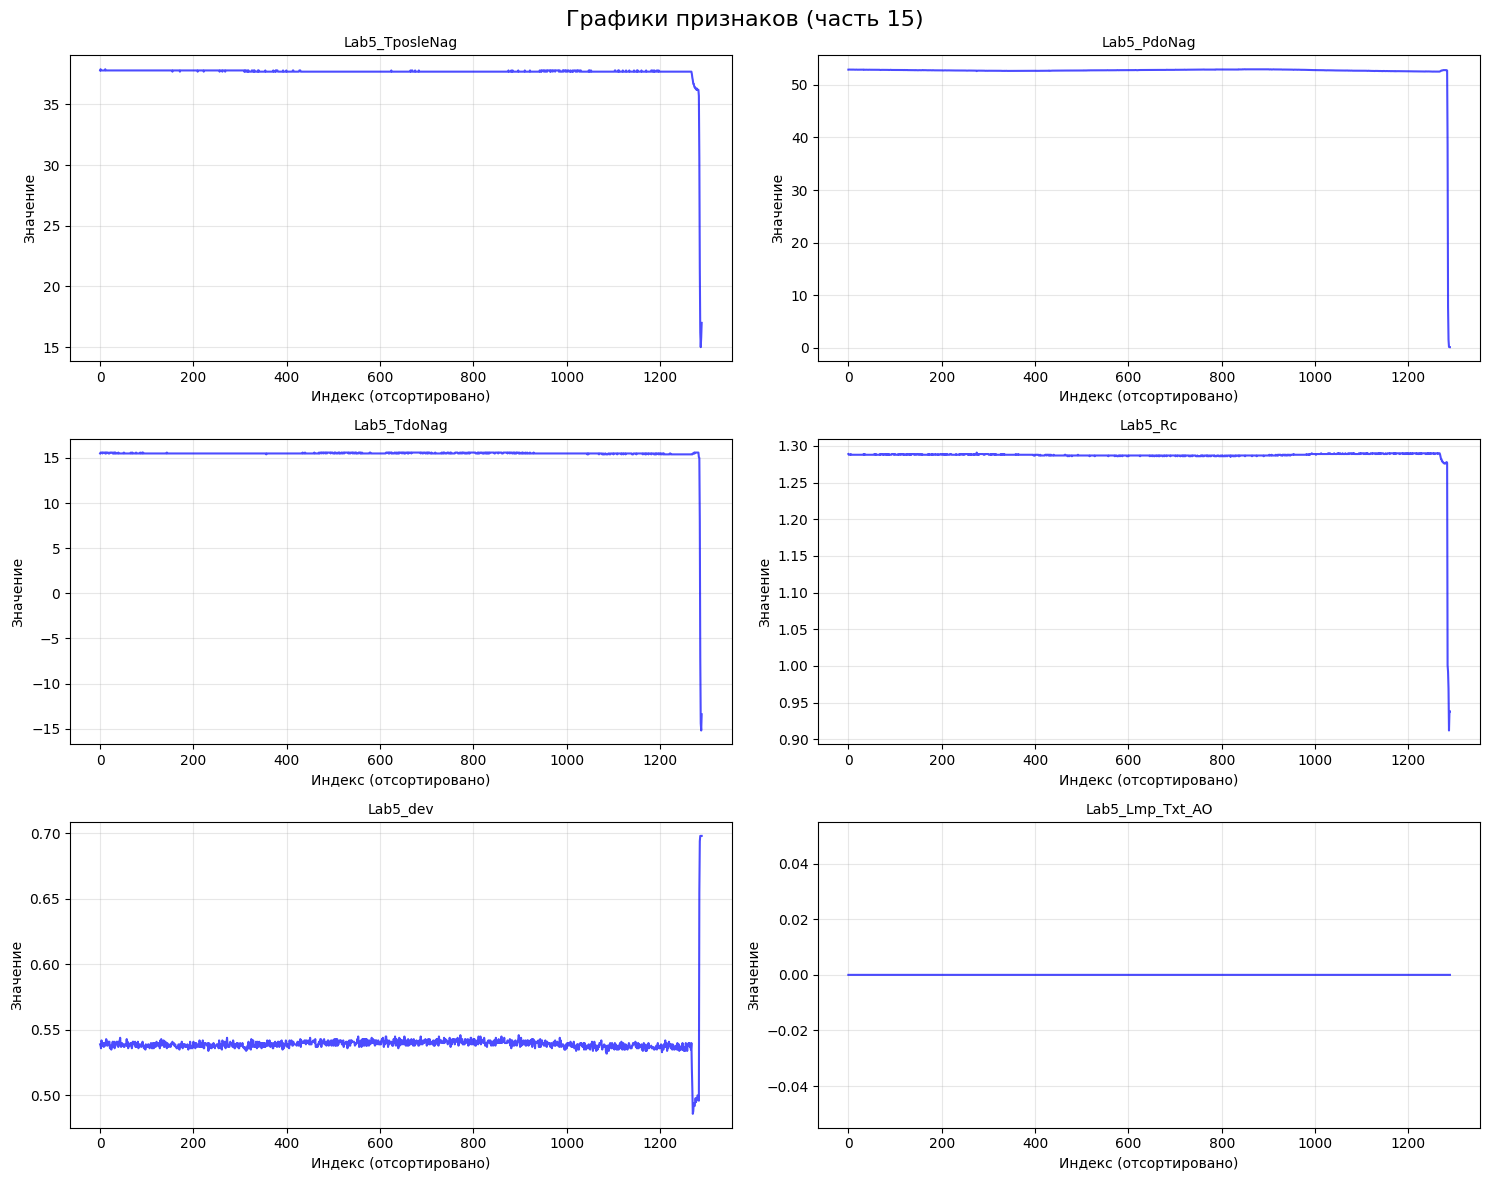

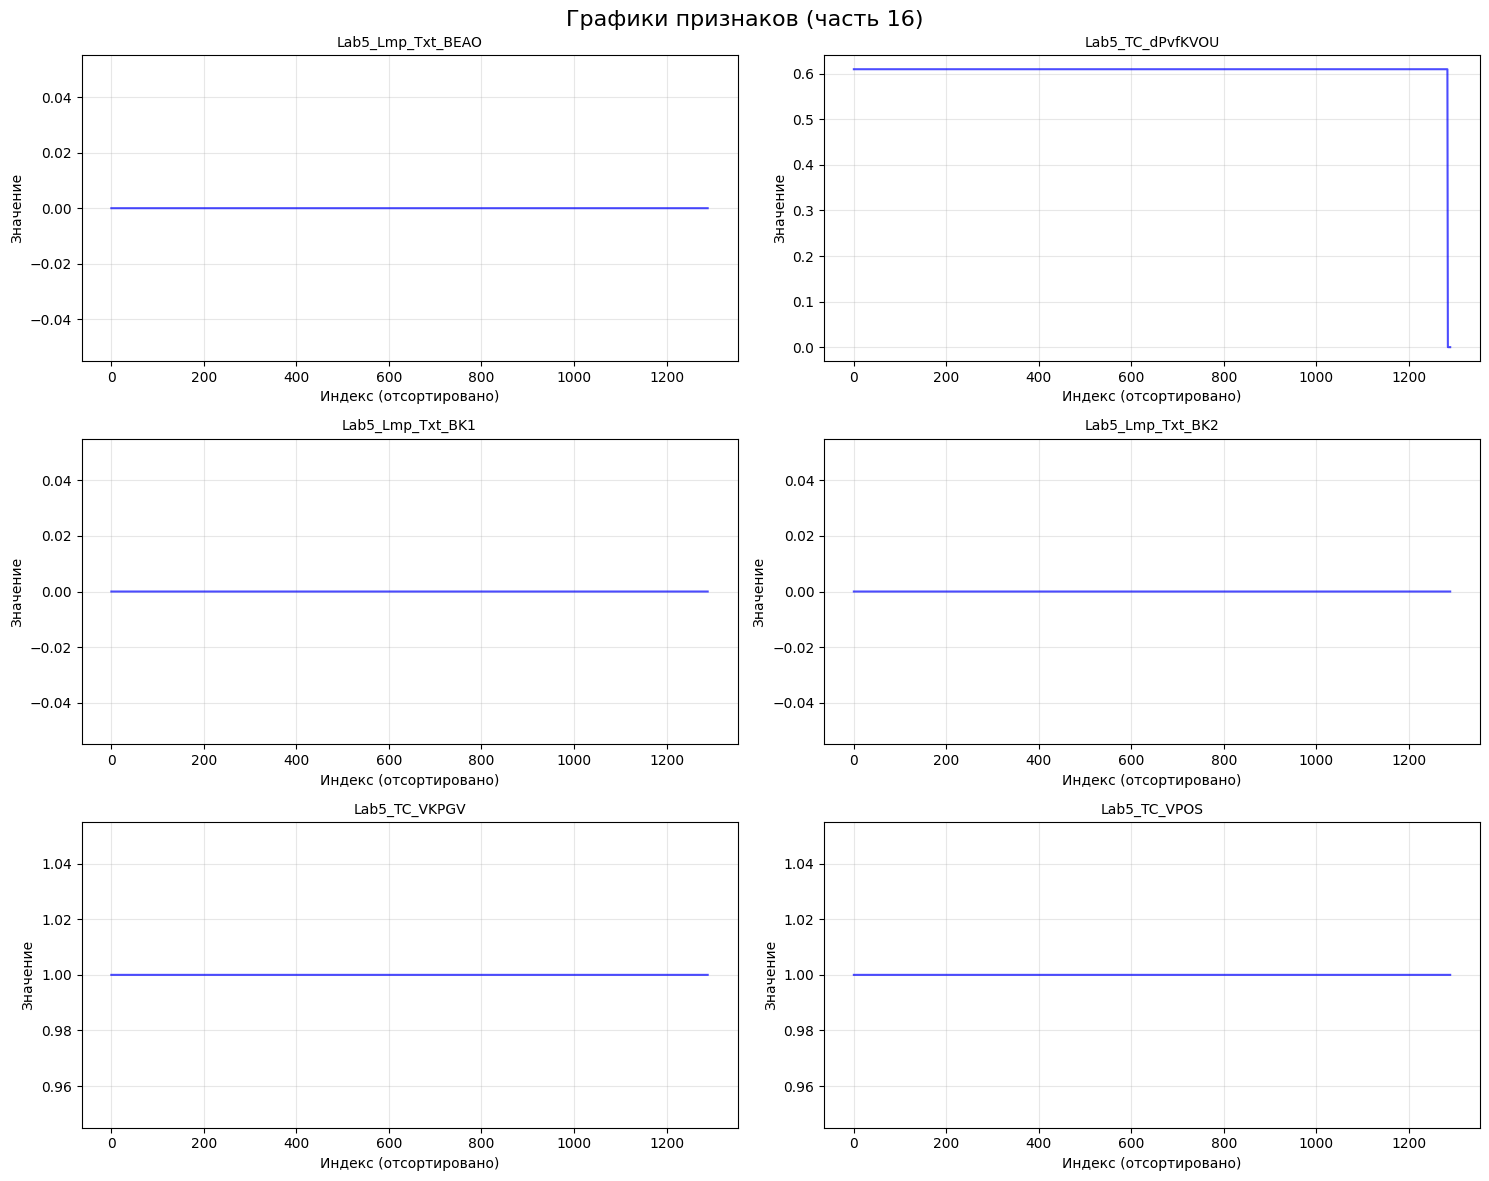

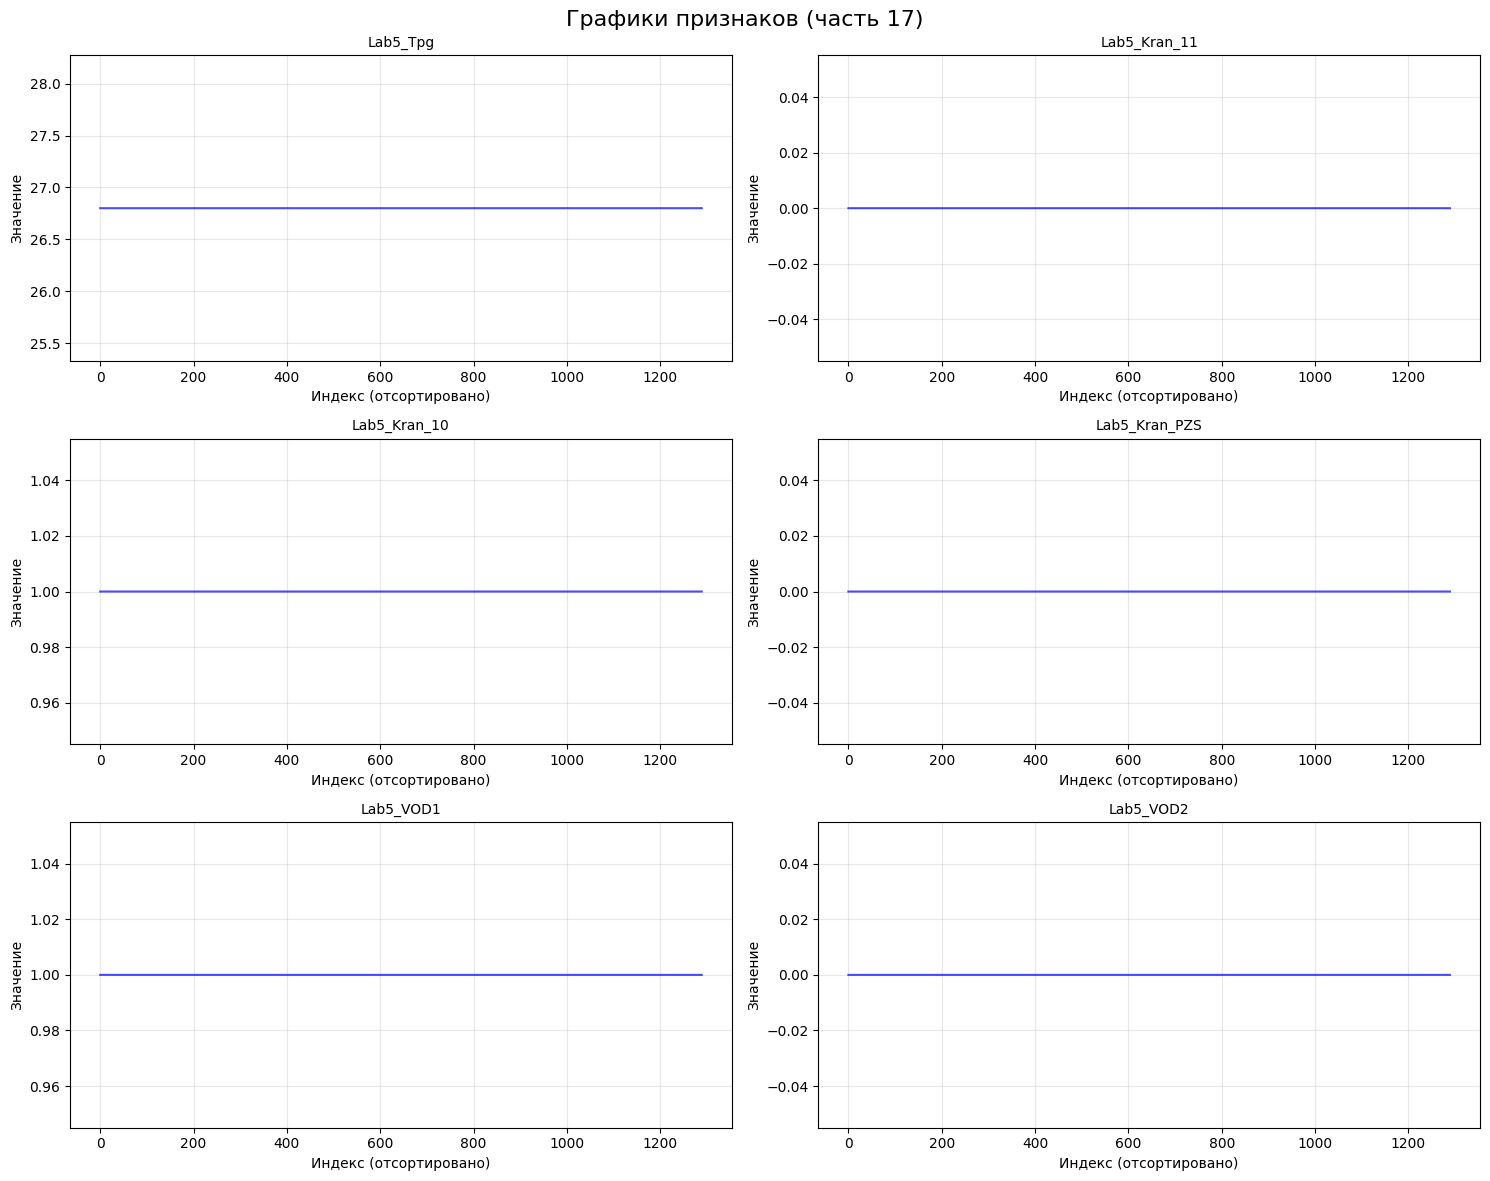

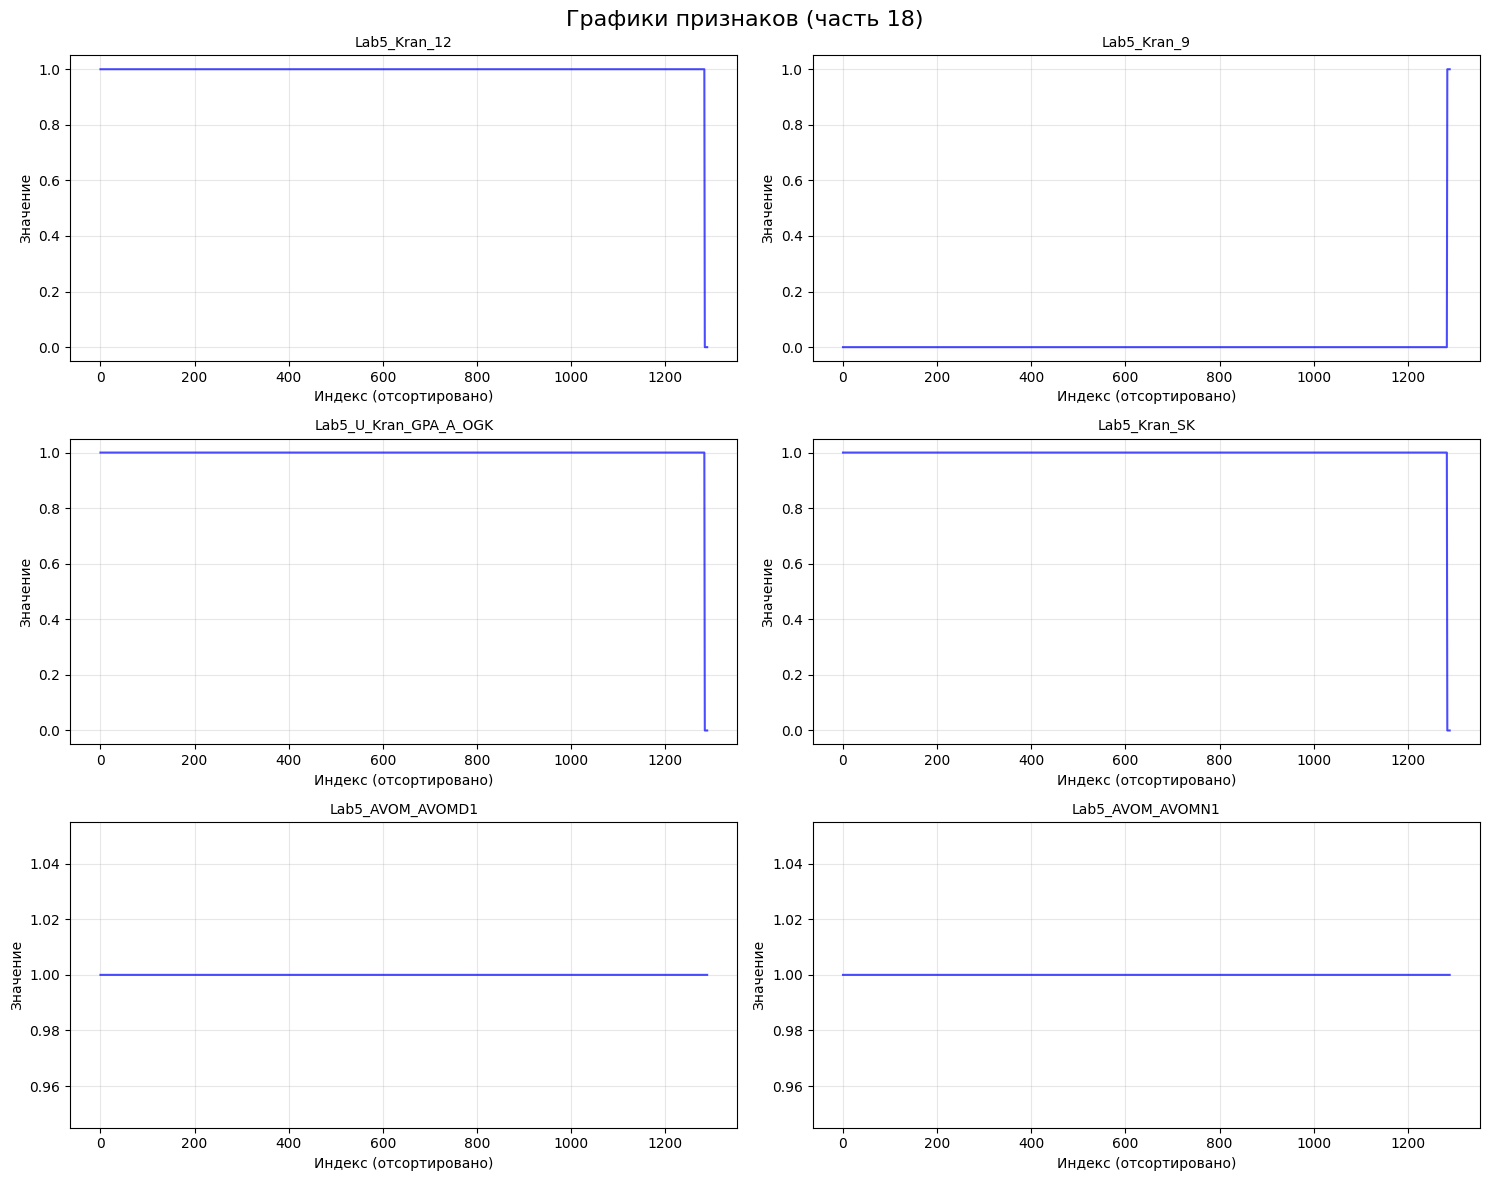

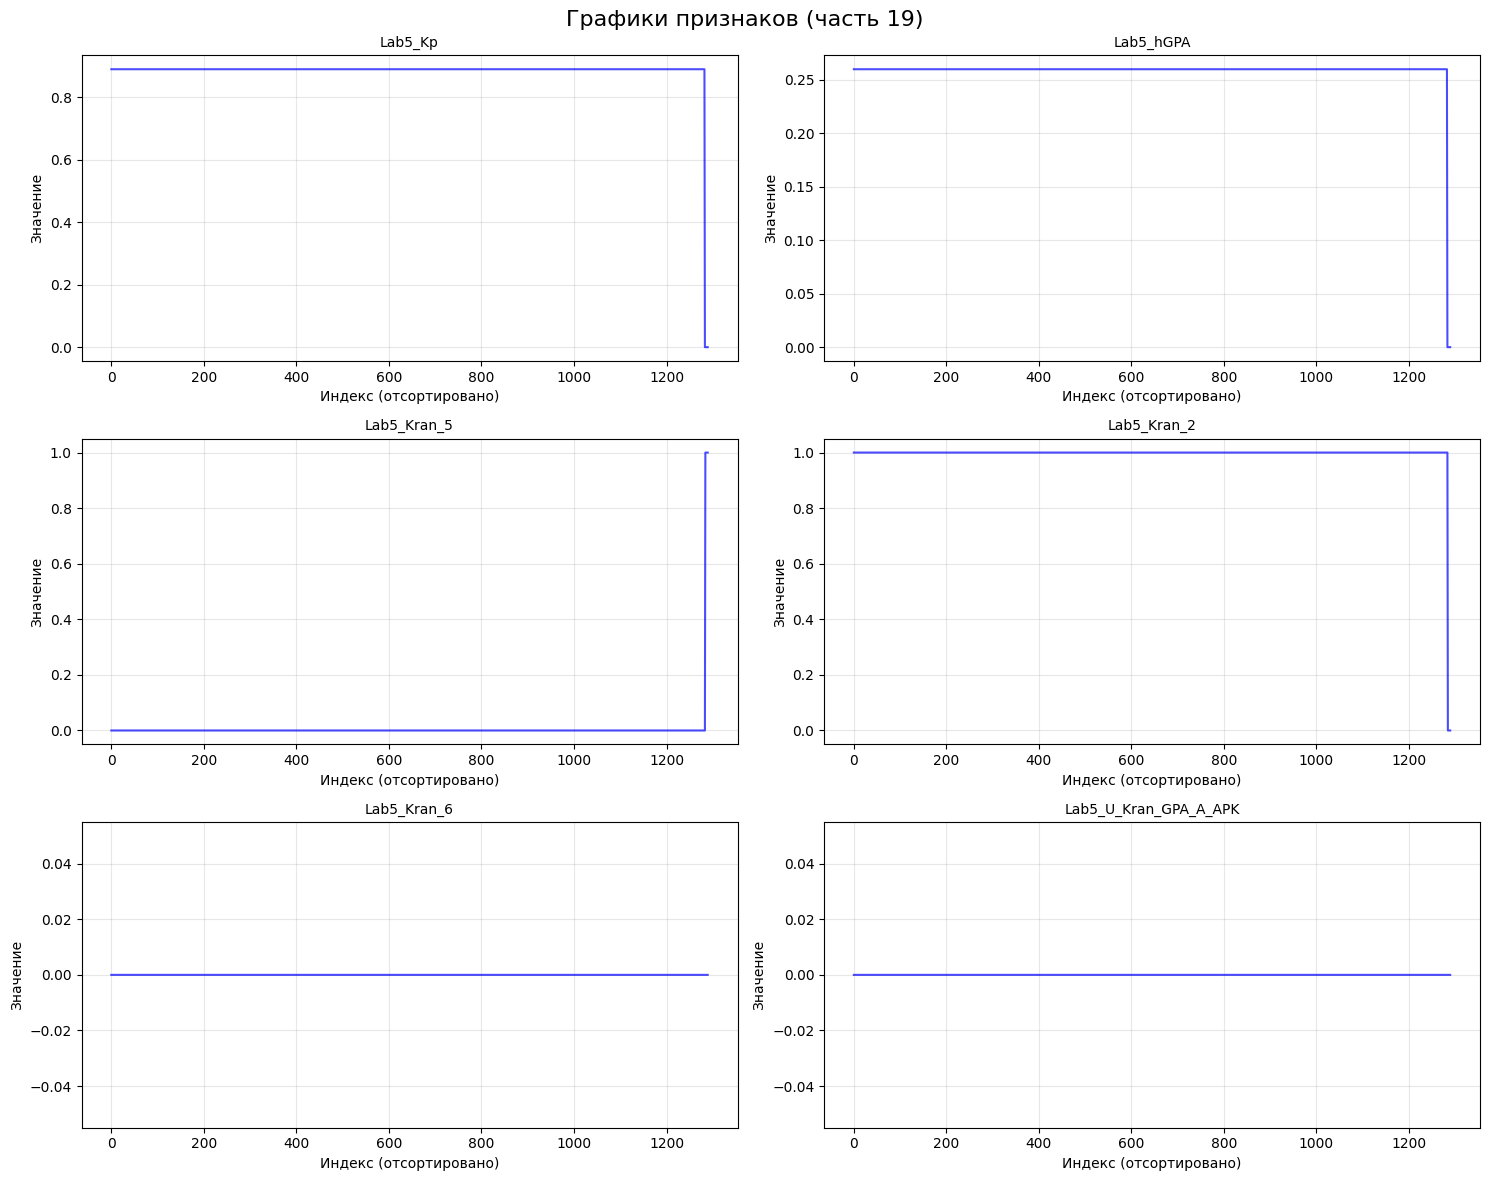

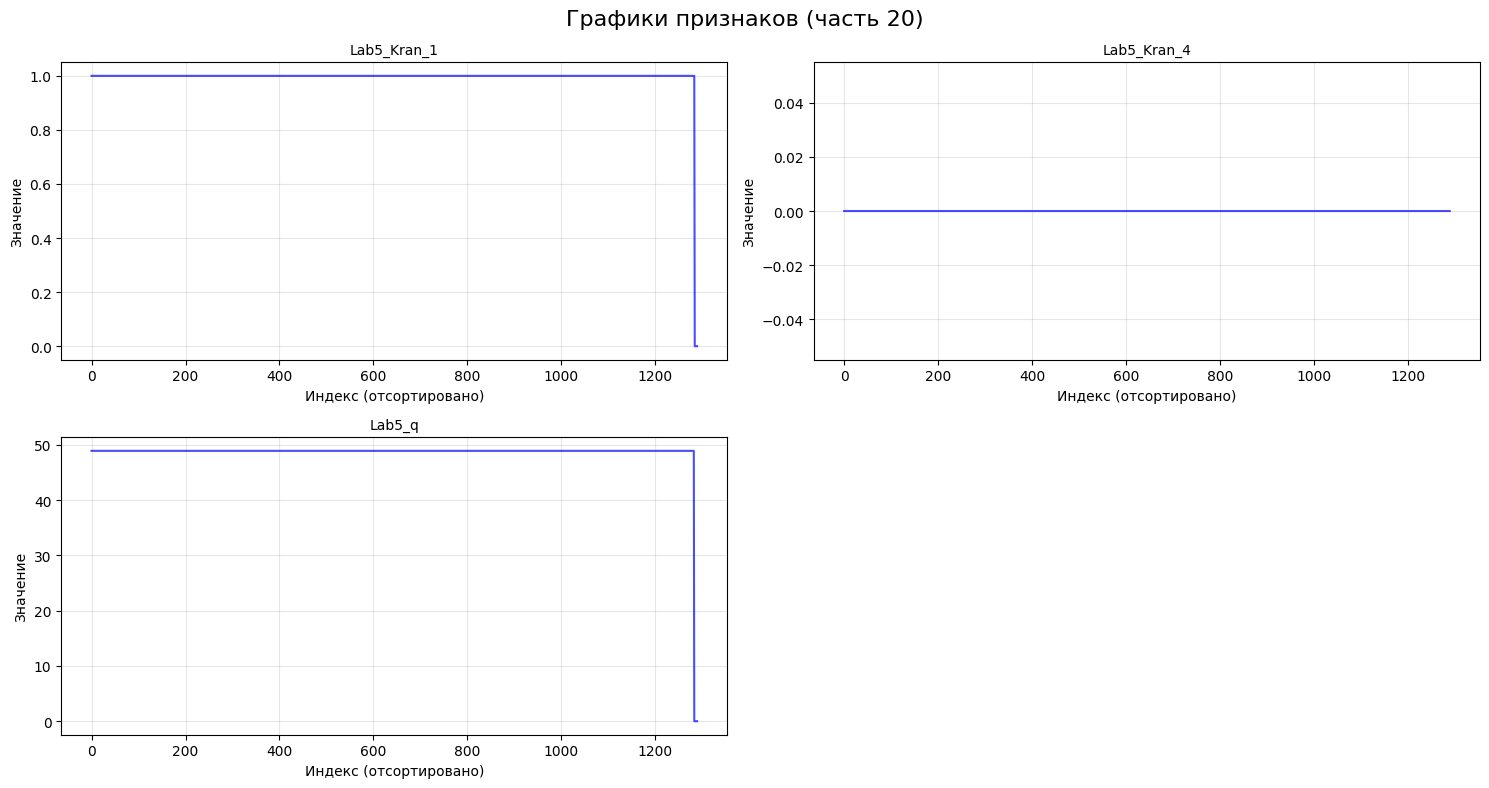

In [11]:
n_cols = len(df.columns)

plots_per_figure = 6
n_figures = (n_cols + plots_per_figure - 1) // plots_per_figure  

for fig_num in range(n_figures):
    start_idx = fig_num * plots_per_figure
    end_idx = min(start_idx + plots_per_figure, n_cols)
    cols_in_figure = df.columns[start_idx:end_idx]
    
    n_plots = len(cols_in_figure)
    n_rows = (n_plots + 1) // 2
    n_cols_grid = 2
    
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(15, 4*n_rows))
    fig.suptitle(f'Графики признаков (часть {fig_num+1})', fontsize=16)
    
    axes_flat = axes.flatten() if n_plots > 1 else [axes]
    
    for idx, col in enumerate(cols_in_figure):
        axes_flat[idx].plot(df[col].index, df[col].values, 
                           linewidth=1.5, color='blue', alpha=0.7)
        axes_flat[idx].set_title(f'{col}', fontsize=10)
        axes_flat[idx].set_xlabel('Индекс (отсортировано)')
        axes_flat[idx].set_ylabel('Значение')
        axes_flat[idx].grid(True, alpha=0.3)
    for idx in range(len(cols_in_figure), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

На основе визуального анализа можно выделить следующие особенности:
1. Часть рядов имеет постоянные значения.
2. Часть рядов относится к бинарным переменным, которые сохраняют свое значение практически в течение всего времени.
3. Часть рядов имеет практически постоянные значения с несколькими местами скачков.
4. Оставшиеся ряды непостоянны с меняющейся динамикой значений в конце ряда.

Выделим отдельно постоянные признаки и признаки со скачками:

In [12]:
const_cols = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=const_cols, errors='ignore')

In [13]:
unique_counts = (
    df
    .nunique(dropna=True)
    .sort_values()
)

pd.set_option("display.max_rows", None)

unique_counts

Lab5_q                      2
Lab5_Kran_2                 2
Lab5_Kran_1                 2
Lab5_TC_dPvfKVOU            2
Lab5_Kran_5                 2
Lab5_Kran_12                2
Lab5_Kran_9                 2
Lab5_U_Kran_GPA_A_OGK       2
Lab5_Kran_SK                2
Lab5_Kp                     2
Lab5_hGPA                   2
Lab5_TdoNag                10
Lab5_G1_T607               10
Lab5_TC_T607               11
Lab5_Pm_sm_N               11
Lab5_dPmg                  13
Lab5_Hpol                  14
Lab5_G2_Fв9                15
Lab5_TC_Pm                 16
Lab5_Rc                    17
Lab5_TposleNag             18
Lab5_Ttg                   19
Lab5_G2_Fтк8               19
Lab5_G2_Fн9                19
Lab5_G2_Fтк9               20
Lab5_G1_T600               23
Lab5_G2_Fс8                26
Lab5_G2_Fc9                27
Lab5_TC_P615               28
Lab5_G4_Р2пр               28
Lab5_G1_P2                 28
Lab5_G1_T1                 30
Lab5_G2_3F3                30
Lab5_dev  

Также удалим ряды, соответствующие значениям бинарных переменных с двумя уникальными значениями:

In [14]:
two_val_cols = [col for col in df.columns if df[col].nunique() <= 2]
df = df.drop(columns=two_val_cols, errors='ignore')
len(df.columns)

83

Все оставшиеся признаки имеют по крайней мере 10 уникальных значений.

# Определение природы порождающего процесса

In [15]:
import nolds


def normalize_series(series: pd.Series):
    """Perform Z normalization"""
    return (series - series.mean()) / series.std()

def lyapunov_hurst_analysis(series):
    results = {}
    # clean_series = series.dropna() # Пропуски отсутствуют - проверено ранее
    
    try:
        results['hurst'] = nolds.hurst_rs(clean_series, # Вычисления показателя Херста с использованием R/S метода (rescaled range)
                                          fit='poly', # Используется полиномиальная регрессия
                                          corrected=True, # Используется поправка Аниса-Ллойда
                                          unbiased=True) # Используется несмещенная оценка дисперсии
    except:
        results['hurst'] = None
    
    if results['hurst'] is not None:
        H = results['hurst']
        if H < 0 or H > 1:
            results['hurst_type'] = 'stationary'
        elif H >= 0 and H < 0.5:
            results['hurst_type'] = 'anti-perst'
        elif H == 0.5: ## Возможно требуется добавление диапазона, так как строгое равенство скорее всего не достигается из-за особенностей вычислений с плавающей точкой
            results['hurst_type'] = 'random_walk'
        elif H > 0.5 and H <= 1:
            results['hurst_type'] = 'persistent'
    else:
        results['hurst_type'] = None
    
    norm_series = normalize_series(clean_series)
    try:
        results['lyapunov'] = nolds.lyap_r(norm_series, # Расчет показателя Ляпунова методом Розенштейна
                                           lag=None, # Автоматический выбор задержки вложения
                                           fit="poly") # Используется полиномиальная регрессия
        results['lyap_type'] = 'chaotic' if results['lyapunov'] > 0 else 'non-chaotic'
    except:
        results['lyapunov'] = None
        results['lyap_type'] = None
    
    return results

In [16]:
lyap_hurst_res = []
for col in df.columns:
    row = {}
    row['col'] = col
    res = lyapunov_hurst_analysis(df[col])
    row.update(res)
    lyap_hurst_res.append(row)

lyap_hurst_df = (
    pd.DataFrame(lyap_hurst_res)
    .sort_values(["hurst", "lyapunov"])
    .reset_index(drop=True)
)
lyap_hurst_df

NameError: name 'clean_series' is not defined

Для большинства рядов показатель Херста говорит о персистентности ряда, а показатель Ляпунова - о хаотичности. Из названия набора данных известно, что он собран по датчикам подшипника в процессе его разрушения. Источник временных рядов может быть объяснением их свойств: в процессе износа подшипника изменяется (увеличивается, на основе визуального анализа графиков) амплитуда его колебаний.

In [ ]:
import math

cols = lyap_hurst_df["col"].tolist()
plots_per_page = 6

for start in range(0, len(cols), plots_per_page):
    subset = cols[start:start + plots_per_page]
    ncols = 2
    nrows = math.ceil(len(subset) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, subset):
        row = lyap_hurst_df.loc[lyap_hurst_df["col"] == col].iloc[0]
        H = row["hurst"]
        H_text = f"{H:.3f}" if pd.notna(H) else "nan"
        process_text = row["hurst_type"]
        lyapunov_text=row["lyap_type"]
        ax.plot(df[col].values, linewidth=1)
        ax.set_xlabel("index")
        ax.set_title(
            f"{col}\nH = {H_text}: {process_text}\nLyapunov: {lyapunov_text}",
            fontsize=9
        )
        ax.grid(True)
    for ax in axes[len(subset):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Вложение временного ряда

В множестве временных рядов есть группа рядов, которые практически постоянны, но имеют два характерных обрыва в конце времени измерения. Выделим эти ряды в отдельную группу и запишем для них точки, в которых произошел обрыв:

In [ ]:
two_drop_cols = ['Lab5_G1_N1', 'Lab5_G1_N2', 'Lab5_G1_N3', 'Lab5_G1_P2', 'Lab5_G1_T4ср', 'Lab5_G3_N3', 'Lab5_G4_Р2пр', 'Lab5_G4_N1пр', 'Lab5_G4_T4пр', 'Lab5_G4_N2', 'Lab5_G4_T4', 'Lab5_Qtg', 'Lab5_PologenieTRK', 'Lab5_Ne', 'Lab5_PposleNag', 'Lab5_TposleNag', 'Lab5_Rc']
print(len(two_drop_cols))
df = df.drop(columns=two_drop_cols, errors='ignore')

Также можно выделить группу почти постоянных рядов с одним характерным обрывом в конце:

In [ ]:
one_drop_cols = ['Lab5_TC_Ptgdg', 'Lab5_TC_Pm', 'Lab5_Hpol', 'Lab5_PdoNag', 'Lab5_TdoNag', 'Lab5_TC_dPvfKVOU']
print(len(one_drop_cols))
df = df.drop(columns=one_drop_cols, errors='ignore')

In [ ]:
print('Всего рядов для анализа: ', len(df.columns))

Проведем факторизацию множества временных рядов: так как визуальный анализ показывает наличие нескольких групп похожих графиков рядов, их можно выделить в классы эквивалентности на основе метрики Чебышева.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform

def plot_k_distance_graph(df: pd.DataFrame, metric: str = 'correlation', scaler_type: str = "standard", k: list = [1, 2, 3, 4]):
    scaler = None
    if scaler_type == "min_max":
        scaler = MinMaxScaler()
    elif scaler_type == "standard":
        scaler = StandardScaler()
    else:
        print(f"Error: use unknown scaler {scaler_type}, use default: standard")
        scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
    
    X = df_scaled.T.values  # строки – датчики, столбцы – временные точки
    n_sensors = X.shape[0]
    print(f"Обработка {n_sensors} временных рядов. Метрика: {metric}...")
    
    # Проверяем, что k не превышает число возможных соседей
    max_k = max(k)
    if max_k >= n_sensors:
        raise ValueError(f"Значение k={max_k} должно быть меньше числа датчиков ({n_sensors}).")
    
    # Вычисление матрицы расстояний
    if metric == 'correlation':
        dist_matrix = squareform(pdist(X, metric='correlation'))
    elif metric == 'l_inf':
        dist_matrix = squareform(pdist(X, metric='chebyshev'))
    elif metric == 'l_1':
        dist_matrix = squareform(pdist(X, metric='cityblock'))
    else:
        raise ValueError("Поддерживаемые метрики: 'correlation', 'l_1', 'l_inf'")
    
    # Создаём 2x2 subplot'ы
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()  # удобно итерироваться
    
    k_distances_dict = {}
    
    for idx, current_k in enumerate(k):
        # NearestNeighbors с предвычисленной матрицей расстояний
        # n_neighbors = k + 1, чтобы исключить саму точку (расстояние 0)
        nn = NearestNeighbors(n_neighbors=current_k + 1, metric='precomputed')
        nn.fit(dist_matrix)
        distances, _ = nn.kneighbors(dist_matrix)
        
        # Расстояние до k-го соседа (последний столбец после исключения себя)
        k_dist = distances[:, -1]
        k_dist_sorted = np.sort(k_dist)
        k_distances_dict[current_k] = k_dist_sorted
        
        ax = axes[idx]
        ax.plot(k_dist_sorted, marker='o', markersize=3, linestyle='-', color='b')
        ax.set_title(f'k = {current_k}', fontsize=12)
        ax.set_xlabel('Индекс ряда (сорт.)')
        ax.set_ylabel(f'Расстояние до {current_k}-го соседа')
        ax.grid(True, linestyle='--', alpha=0.7)
    
    for j in range(len(k), 4):
        fig.delaxes(axes[j])
    
    fig.suptitle(f'k-distance Graph (метрика = {metric})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return df_scaled, dist_matrix, k_distances_dict

In [ ]:
df_scaled, dists, k_dists_sorted = plot_k_distance_graph(df, metric='l_inf', scaler_type="min_max")

Анализ графика при $k=1, 2, 3, 4$ показывает, что среди оставшихся рядов наиболее вероятно 4 выделяются в единый кластер, так как дальше для 1-го, 2-го и 3-го ближайшего соседа идет резкий рост расстояний. При $k=4$ расстояния до ближайшего соседа начинаются уже не с нуля.

In [ ]:
import math
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

def plot_ts_clusters(df_scaled: pd.DataFrame, dist_matrix: np.ndarray, eps: float, plot=True):
    dbscan = DBSCAN(eps=eps, min_samples=1, metric='precomputed')
    labels = dbscan.fit_predict(dist_matrix)
    sensor_names = df_scaled.columns
    unique_clusters = sorted(list(set(labels)))
    n_clusters = len(unique_clusters)
    print(f"Порог eps = {eps:.4f}")
    print(f"Всего выделено классов эквивалентности (кластеров): {n_clusters}")
    plots_per_fig = 6
    cols = 2
    if plot:
        for i in range(0, n_clusters, plots_per_fig):
            current_clusters = unique_clusters[i : i + plots_per_fig]
            n_current = len(current_clusters)
            rows = math.ceil(n_current / cols)
            
            fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
            fig.suptitle(f'Паттерны сигналов: Кластеры {i+1} — {i+n_current} из {n_clusters}', 
                        fontsize=16, y=1.02)
            
            if isinstance(axes, np.ndarray):
                axes_flat = axes.flatten()
            else:
                axes_flat = [axes]
            for idx, cluster_id in enumerate(current_clusters):
                ax = axes_flat[idx]
                sensors_in_cluster = sensor_names[labels == cluster_id]
                for sensor in sensors_in_cluster:
                    ax.plot(df_scaled.index, df_scaled[sensor], alpha=0.7, linewidth=1.5, label=sensor)
                ax.set_title(f'Класс {cluster_id} (Рядов: {len(sensors_in_cluster)})', fontsize=12)
                ax.set_xlabel('Время / Отсчеты')
                ax.set_ylabel('Нормированная амплитуда')
                ax.grid(True, linestyle='--', alpha=0.6)
                if len(sensors_in_cluster) <= 10:
                    ax.legend(loc='upper right', fontsize='small', ncol=2)
            for idx in range(n_current, len(axes_flat)):
                fig.delaxes(axes_flat[idx])
                
            plt.tight_layout()
            plt.show()

In [ ]:
plot_ts_clusters(df_scaled=df_scaled, dist_matrix=dists, eps=1.5, plot=True)

In [ ]:
df_scaled, dists, k_dists_sorted = plot_k_distance_graph(df, metric='l_inf', scaler_type="standard")

In [ ]:
plot_ts_clusters(df_scaled=df_scaled, dist_matrix=dists, eps=1.5, plot=True)

Получено 56 кластеров, большая часть которых состоит из одного ряда. Для каждого кластера из нескольких рядов выберем один и выполним вложение только для него.

In [ ]:
repeated_cols = ['Lab5_G1_T607', 'Lab5_G2_F3', 'Lab5_G3_КНД', 'Lab5_G3_ПО_СТ', 'Lab5_G3_Турбина_ГГ']
df = df.drop(columns=repeated_cols, errors='ignore')
len(df.columns)

In [ ]:
df.columns

## Подбор параметров равномерного и неравномерного вложения

Для выбора параметров равномерного вложения использовались методы F1NN и минимум взаимной информации, для неравномерного вложения - метод PECUZAL.